# OSCAR: Object-Semantics Aligned Pre-training for Vision-Language Tasks

# https://arxiv.org/pdf/2004.06165

**Li et al., Microsoft Research & University of Washington — ECCV 2020**

---

## Abstract

OSCAR is a Vision-Language Pre-training (VLP) method that introduces **object tags** detected in images as **anchor points** to bridge the semantic gap between visual and textual modalities. Pre-trained on 6.5 million image-text pairs, OSCAR achieves state-of-the-art results on six established V+L understanding and generation benchmarks.

---

## Problems

Existing VLP methods concatenate image region features and word embeddings, relying solely on self-attention to learn cross-modal alignment. This naive approach suffers from two fundamental issues:

1. **Ambiguity**: Region features extracted via Faster R-CNN are over-sampled and spatially overlapping, making visual embeddings indistinct. For example, the features for *dog* and *couch* can be nearly indistinguishable due to region overlap.

2. **Lack of Grounding**: VLP is inherently weakly supervised — there are no explicit alignment labels between image regions and text tokens. The model must discover correspondences entirely from co-occurrence statistics, which is noisy and inefficient.

---

## Proposed Solution

OSCAR introduces **object tags** — textual labels of salient objects detected in images — as a third modality that acts as an **anchor** between the visual and linguistic spaces.

The key insight:

> Salient objects in an image are frequently mentioned in the paired caption text. Since object tags exist in both the linguistic space (as words) and the visual space (as detected regions), they serve as natural bridges for cross-modal alignment.

On MS COCO, the percentage of image-text pairs sharing at least 1, 2, or 3 object tags is **49.7%, 22.2%, and 12.9%**, respectively, validating this assumption.

---

## Purpose

To significantly ease and accelerate cross-modal semantic alignment learning in VLP by grounding visual region features in a well-structured linguistic semantic space, thereby improving both parameter efficiency and downstream task performance.

---

## Methodology

### Input Representation

Each training sample is reformulated as a **Word-Tag-Image triple**:

$$x = (w, q, v)$$

where:
- $w = \{w_1, \ldots, w_T\}$ — word embeddings of the paired text
- $q = \{q_1, \ldots, q_M\}$ — word embeddings of object tags detected from the image
- $v = \{v_1, \ldots, v_K\}$ — region feature vectors from Faster R-CNN

Each region feature $v_k$ is formed by concatenating the visual feature $v' \in \mathbb{R}^{2048}$ with position coordinates $z \in \mathbb{R}^{4 \text{ or } 6}$, then projecting to match the BERT embedding dimension.

The input can be viewed from two perspectives:

$$x = [\underbrace{w}_{\text{language}},\ \underbrace{q,\ v}_{\text{image}}] = [\underbrace{w,\ q}_{\text{language (dictionary)}},\ \underbrace{v}_{\text{image}}] = x'$$

### Pre-training Objectives

**1. Masked Token Loss (MTL) — Dictionary View**

The discrete token sequence $h = [w, q]$ is randomly masked at 15% probability. The model predicts the masked token $h_i$ from its context and all image features:

$$\mathcal{L}_{\text{MTL}} = -\mathbb{E}_{(v,h) \sim \mathcal{D}} \log p(h_i \mid h_{\backslash i},\ v)$$

This is analogous to BERT's masked language modeling, extended with visual grounding.

**2. Contrastive Loss (CL) — Modality View**

For each triple, the image representation is defined as $h' = [q, v]$. With 50% probability, $q$ is replaced with a randomly sampled tag sequence from the dataset (a "polluted" sample). A binary classifier $f(\cdot)$ on the $[\text{CLS}]$ token predicts whether the pair is aligned ($y=1$) or polluted ($y=0$):

$$\mathcal{L}_C = -\mathbb{E}_{(h', w) \sim \mathcal{D}} \log p(y \mid f(h', w))$$

**Total Pre-training Objective:**

$$\mathcal{L}_{\text{Pre-training}} = \mathcal{L}_{\text{MTL}} + \mathcal{L}_C$$

### Model Variants

| Variant | Backbone | Hidden Size $H$ | Training Steps |
|---------|----------|-----------------|----------------|
| OSCAR$_B$ | BERT-base | 768 | $\geq$ 1.0M |
| OSCAR$_L$ | BERT-large | 1024 | $\geq$ 900K |

### Downstream Tasks

OSCAR is fine-tuned on seven V+L tasks:

| Category | Tasks |
|----------|-------|
| Understanding | VQA, GQA, NLVR2, Image-Text Retrieval, Text-Image Retrieval |
| Generation | Image Captioning (COCO), Novel Object Captioning (NoCaps) |

---

## Results

### Overall Performance vs. State-of-the-Art

| Task | Prior SoTA$_L$ | OSCAR$_B$ | OSCAR$_L$ | $\Delta$ |
|------|---------------|-----------|-----------|----------|
| Image Retrieval R@1 | 51.7 | 54.0 | **57.5** | +5.8 |
| Text Retrieval R@1 | 66.6 | 70.0 | **73.5** | +6.9 |
| Image Captioning CIDEr | 129.3 | 137.6 | **140.0** | +10.7 |
| VQA (test-std) | 73.40 | 73.44 | **73.82** | +0.42 |
| NoCaps CIDEr (overall) | 73.1 | 78.8 | **80.9** | +7.8 |
| NLVR2 (test-P) | 79.50 | 78.36 | **80.37** | +0.87 |

OSCAR$_B$ (base-sized) surpasses the prior large-model SoTA on most tasks, demonstrating high **parameter efficiency**.

### Ablation: Effect of Object Tags

Fine-tuning learning curves (Fig. 6 in paper) show that models trained with object tags:
- Converge **significantly faster** than tag-free baselines
- Require only **half the training time** to match the baseline's final performance on VQA and retrieval tasks
- Performance ordering across all tasks: No Tags $<$ Predicted Tags $<$ Ground-truth Tags

### Ablation: Attention Interaction

Experiments varying attention masks confirm that full attention across all three components $(w\text{-}v, w\text{-}q, v\text{-}q)$ is essential. Removing word-tag ($w\text{-}q$) attention degrades retrieval R@1 by ~2 points, while removing region features ($v$-only) causes catastrophic failure (~32 R@1 vs. 77).

### t-SNE Visualization

The learned embedding space of OSCAR shows:
- **Intra-class**: Visual and textual representations of the same object (e.g., *person*, *zebra*) are tightly clustered and nearly overlapping
- **Inter-class**: Semantically related objects cluster together while remaining separable; the tag-free baseline shows significant inter-class confusion (e.g., *bench*, *chair*, *couch* collapse into a single cluster)

---

## Conclusions

1. **Object tags as anchors** are a simple yet highly effective mechanism to reduce the alignment learning burden in VLP, transforming a purely weakly-supervised problem into a better-grounded one.

2. The **two-loss framework** (MTL + Contrastive) provides complementary learning signals from dictionary and modality perspectives, despite being simpler than competing methods.

3. OSCAR is **parameter-efficient**: the base model outperforms existing large-model VLP baselines across most tasks, while being pre-trained on fewer image-text pairs (6.5M vs. 9.6M for UNITER).

4. The framework is **task-agnostic**: a single pre-trained model adapts to both understanding and generation tasks through standard fine-tuning, with no task-specific architectural changes required.

5. **Future direction**: More accurate object detectors (closing the gap between predicted and ground-truth tags) would directly and predictably improve OSCAR's performance across all downstream tasks.

# Mathematical & Statistical Content in OSCAR

---

## 1. Input Representation

### Feature Vectors

Region features from Faster R-CNN are represented as:

$$v' \in \mathbb{R}^P, \quad P = 2048$$

Each detected region also has a position vector:

$$z \in \mathbb{R}^R, \quad R = 4 \text{ or } 6$$

The 4-dimensional case encodes $(x_1, y_1, x_2, y_2)$ — top-left and bottom-right corners.  
The 6-dimensional case additionally encodes width and height.

These are concatenated to form a position-sensitive region feature, then linearly projected:

$$v_k = W \cdot [v'_k;\ z_k], \quad W \in \mathbb{R}^{H \times (P+R)}$$

where $H$ is the BERT hidden size (768 for base, 1024 for large). This projection ensures visual features live in the **same vector space** as word embeddings.

---

## 2. Triple Input Structure

Each training sample is a triple:

$$x = (w,\ q,\ v)$$

| Symbol | Meaning | Type |
|--------|---------|------|
| $w = \{w_1, \ldots, w_T\}$ | Word embeddings of caption text | Language |
| $q = \{q_1, \ldots, q_M\}$ | Word embeddings of detected object tags | Language |
| $v = \{v_1, \ldots, v_K\}$ | Region feature vectors from image | Vision |

The input admits two equivalent views:

$$x = \left[\underbrace{w}_{\text{language}},\ \underbrace{q,\ v}_{\text{image}}\right]
= \left[\underbrace{w,\ q}_{\text{dictionary (linguistic)}},\ \underbrace{v}_{\text{visual}}\right] = x'$$

**Interpretation:** The first grouping separates modalities (text vs. image). The second separates semantic spaces (linguistic dictionary vs. visual features). This dual-view motivates the two separate loss functions.

---

## 3. Pre-training Objective 1 — Masked Token Loss (MTL)

### Concept

Define the discrete token sequence as:

$$h = [w,\ q]$$

At each training iteration, each token $h_i \in h$ is independently masked with probability:

$$p(\text{mask}) = 0.15$$

The masked token is replaced with a special $[\text{MASK}]$ symbol. The model must recover $h_i$ from:
- All remaining tokens $h_{\backslash i}$ (the unmasked context)
- All image region features $v$

### Loss Function

$$\mathcal{L}_{\text{MTL}} = -\mathbb{E}_{(v,h) \sim \mathcal{D}}\ \log\ p(h_i \mid h_{\backslash i},\ v)$$

This is **cross-entropy loss** over the vocabulary, applied to each masked position.

**Role:** Inherited from BERT's masked language modeling, but extended to cover both word tokens and object tags jointly. Forcing the model to recover masked tags while attending to image regions encourages **grounded language understanding** — the model must learn which image regions correspond to which words.

---

## 4. Pre-training Objective 2 — Contrastive Loss (CL)

### Concept

Group the image representation as:

$$h' = [q,\ v]$$

For each training triple $(h', w)$, with probability **50%**, replace $q$ with a randomly sampled tag sequence $\tilde{q}$ from the dataset $\mathcal{D}$. This creates a **polluted** (negative) sample:

$$\tilde{h}' = [\tilde{q},\ v]$$

Define a binary label:

$$y = \begin{cases} 1 & \text{if } h' \text{ is the original (aligned) image representation} \\ 0 & \text{if } h' \text{ is polluted (mismatched tags)} \end{cases}$$

A fully-connected binary classifier $f(\cdot)$ operates on the $[\text{CLS}]$ token output — the fused vision-language representation.

### Loss Function

$$\mathcal{L}_C = -\mathbb{E}_{(h', w) \sim \mathcal{D}}\ \log\ p(y \mid f(h',\ w))$$

This is **binary cross-entropy loss**.

**Role:** Forces the model to distinguish between genuinely aligned image-text pairs and corrupted ones. The object tags $q$ serve as the proxy for the image — if the tags are inconsistent with the text, the model must detect this. This directly trains **cross-modal alignment discrimination**.

---

## 5. Total Pre-training Objective

The two losses are combined with equal weighting:

$$\mathcal{L}_{\text{Pre-training}} = \mathcal{L}_{\text{MTL}} + \mathcal{L}_C$$

**Role:** Each loss captures a complementary aspect of alignment:

| Loss | View | What it learns |
|------|------|----------------|
| $\mathcal{L}_{\text{MTL}}$ | Dictionary (linguistic space) | Grounded token recovery |
| $\mathcal{L}_C$ | Modality (image vs. text) | Image-text pair coherence |

---

## 6. Optimizer and Training Hyperparameters

The **AdamW** optimizer is used, which minimizes the loss with weight decay regularization:

$$\theta_{t+1} = \theta_t - \alpha \cdot \left(\hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon) + \lambda \theta_t\right)$$

where $\alpha$ is the learning rate, $\hat{m}_t$ and $\hat{v}_t$ are bias-corrected first and second moment estimates, and $\lambda$ is the weight decay coefficient.

| Variant | Learning Rate $\alpha$ | Batch Size | Steps |
|---------|----------------------|------------|-------|
| OSCAR$_B$ | $5 \times 10^{-5}$ | 768 | $\geq 1.0 \times 10^6$ |
| OSCAR$_L$ | $1 \times 10^{-5}$ | 512 | $\geq 9.0 \times 10^5$ |

Sequence lengths:
$$|h| \leq 35 \text{ tokens}, \quad |v| \leq 50 \text{ regions}$$

---

## 7. Evaluation Metrics

### 7.1 Retrieval — Recall at K

$$R@K = \frac{\text{number of queries with correct match in top-}K \text{ results}}{\text{total number of queries}}$$

Reported for $K \in \{1, 5, 10\}$ on both 1K and 5K COCO test sets.

### 7.2 Image Captioning Metrics

**BLEU@4** — geometric mean of 4-gram precision with brevity penalty:

$$\text{BLEU@4} = BP \cdot \exp\left(\frac{1}{4} \sum_{n=1}^{4} \log p_n\right)$$

**METEOR (M)** — harmonic mean of precision and recall on unigrams with stemming and synonym matching.

**CIDEr (C)** — consensus-based metric using TF-IDF weighted $n$-gram similarity:

$$\text{CIDEr}_n(c, S) = \frac{1}{|S|} \sum_{s \in S} \frac{g^n(c) \cdot g^n(s)}{\|g^n(c)\| \cdot \|g^n(s)\|}$$

where $g^n(\cdot)$ is the TF-IDF weighted vector of $n$-grams. CIDEr is the primary metric for captioning.

**SPICE (S)** — scene graph based metric measuring semantic propositional content.

### 7.3 VQA / GQA / NLVR2

Standard **classification accuracy**:

$$\text{Accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}$$

For VQA specifically, **soft target scoring** is used: each answer is assigned a soft score based on human annotator agreement, and cross-entropy is computed against these soft labels rather than one-hot targets.

---

## 8. Self-Critical Sequence Training (SCST)

Used in image captioning fine-tuning to optimize CIDEr directly (a non-differentiable metric). The REINFORCE-based reward is:

$$\nabla_\theta \mathcal{L}_{\text{SCST}} = -\mathbb{E}_{w^s \sim p_\theta}\left[(r(w^s) - r(\hat{w})) \cdot \nabla_\theta \log p_\theta(w^s)\right]$$

where:
- $w^s$ is a sampled caption
- $\hat{w}$ is the greedy baseline caption
- $r(\cdot)$ is the CIDEr reward function

**Role:** Directly maximizes the evaluation metric rather than token-level cross-entropy, improving sequence-level quality.

---

## 9. t-SNE Dimensionality Reduction

Used for qualitative visualization of learned embedding spaces. t-SNE minimizes the KL divergence between high-dimensional and low-dimensional pairwise similarity distributions:

$$\mathcal{L}_{\text{t-SNE}} = KL(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

where:

$$p_{ij} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma^2)}{\sum_{k \neq l} \exp(-\|x_k - x_l\|^2 / 2\sigma^2)}, \quad
q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

**Role:** Provides 2D visualizations comparing the cross-modal alignment quality of OSCAR vs. the tag-free baseline, confirming that object tags bring visual and textual representations of the same object closer together.

---

## 10. Dataset Scale

$$|\mathcal{D}| = 6.5 \times 10^6 \text{ image-text-tag triples}, \quad |\mathcal{I}| = 4.1 \times 10^6 \text{ unique images}$$

Sources: COCO, Conceptual Captions (CC), SBU, Flickr30k, VQA, GQA, VG-QA.

The dataset is smaller than UNITER ($9.6 \times 10^6$ pairs) yet OSCAR achieves superior results, quantifying the efficiency gain from the anchor-point approach.

---

## Summary Table

| Mathematical Element | Type | Role in OSCAR |
|----------------------|------|---------------|
| $v' \in \mathbb{R}^{2048}$, linear projection $W$ | Linear algebra | Align visual features to BERT embedding space |
| Triple $(w, q, v)$ | Set notation | Unified multi-modal input formulation |
| $\mathcal{L}_{\text{MTL}}$ | Cross-entropy (NLL) | Grounded masked token prediction |
| $\mathcal{L}_C$ | Binary cross-entropy | Image-text pair alignment discrimination |
| $\mathcal{L}_{\text{Pre-training}} = \mathcal{L}_{\text{MTL}} + \mathcal{L}_C$ | Composite loss | Joint pre-training objective |
| AdamW | First/second moment optimization | Stable pre-training with weight decay |
| R@K | Ranking statistic | Retrieval task evaluation |
| BLEU@4, METEOR, CIDEr, SPICE | NLP metrics | Captioning quality evaluation |
| Soft target VQA scoring | Probabilistic labeling | Human-agreement-aware answer scoring |
| SCST / REINFORCE | Policy gradient | Direct CIDEr metric optimization |
| t-SNE (KL divergence) | Manifold learning | Cross-modal alignment visualization |

# OSCAR — Structured Research Gap & Solution Analysis

| # | Problem / Research Gap | Limitation in Prior Work | OSCAR's Proposed Solution |
|---|------------------------|--------------------------|---------------------------|
| 1 | **Visual Ambiguity in Region Features** | Region features extracted via Faster R-CNN are over-sampled, causing heavy spatial overlap between adjacent regions. This renders the extracted visual embeddings ambiguous and indistinct — e.g., features for *dog* and *couch* become nearly inseparable in the visual feature space. | Object tags are projected into the **pre-trained linguistic semantic space**, where *dog* and *couch* are clearly separable. The linguistic space provides a more discriminative and unambiguous representation of visual content than raw region features. |
| 2 | **Lack of Explicit Cross-Modal Grounding** | VLP is inherently a weakly-supervised problem: no explicit alignment labels exist between image regions and text tokens. Prior methods rely entirely on self-attention to discover correspondences from co-occurrence statistics alone, making alignment learning noisy and unreliable. | Detected object tags — present in both the image (as regions) and the text (as words) — serve as **anchor points** that explicitly bridge the two modalities, converting a purely implicit alignment problem into a partially supervised one. |
| 3 | **Brute-Force Alignment via Self-Attention** | Existing VLP methods simply concatenate visual region features and word embeddings and rely on Transformer self-attention to learn image-text alignment from scratch. This requires the model to simultaneously learn feature representation and cross-modal correspondence, which is computationally expensive and sample-inefficient. | By supplying object tags as a shared linguistic signal in both modalities, OSCAR **significantly reduces the search space** for alignment learning. The model can leverage pre-trained BERT's existing knowledge of word-tag correspondences, guiding attention toward semantically relevant regions from early in training. |
| 4 | **Slow and Sample-Inefficient Fine-Tuning** | Without structural grounding, VLP models require many fine-tuning epochs to converge on downstream tasks. The absence of anchor points forces the model to re-learn alignment signals at fine-tuning time, reducing practical efficiency. | Ablation studies (Fig. 6) show that OSCAR with predicted object tags reaches the baseline's final performance using **only half the training time** on VQA and image retrieval, demonstrating substantially improved convergence speed and training efficiency. |
| 5 | **Limited Generalization to Novel Objects** | Prior captioning models trained on COCO fail to describe objects outside their training vocabulary, as visual features have no grounding in an open linguistic space. The NoCaps benchmark exposes this generalization gap directly. | By grounding region features in **pre-trained word embedding space** through object tags, OSCAR inherits the open-vocabulary generalization of language models. On NoCaps, OSCAR with constrained beam search substantially outperforms prior methods on near-domain and out-of-domain splits. |
| 6 | **No Unified Pre-training Objective for Both Modality and Semantic Views** | Prior methods typically employ a single pre-training objective (e.g., masked language modeling or image-text matching), which captures only one perspective of cross-modal correspondence and fails to jointly optimize both intra-space and inter-space alignment. | OSCAR introduces a **dual-objective pre-training scheme**: (1) Masked Token Loss ($\mathcal{L}_{\text{MTL}}$) optimizes grounded token recovery from the dictionary/semantic view; (2) Contrastive Loss ($\mathcal{L}_C$) optimizes modality-level image-text coherence. Together they provide complementary and more complete alignment supervision. |
| 7 | **Parameter Inefficiency of Large VLP Models** | State-of-the-art VLP models such as UNITER-Large require both larger model sizes and larger pre-training corpora (9.6M pairs) to achieve competitive performance, raising computational and data cost barriers. | OSCAR$_B$ (BERT-base scale, pre-trained on 6.5M pairs) **outperforms prior large-scale VLP models** on most benchmarks, demonstrating that structural grounding via object tags improves parameter and data efficiency without requiring architectural scaling. |

In [ ]:
# =============================================================================
# OSCAR: Object-Semantics Aligned Pre-training — Simplified Educational Implementation
# =============================================================================
# This implementation captures the CORE IDEAS of OSCAR:
#   1. A triple input structure: (text/caption, object tags, image features)
#   2. Masked Token Loss (MTL) — predict masked tokens using context + image
#   3. Contrastive Loss (CL)  — distinguish aligned vs. polluted image-text pairs
#   4. A shared Transformer encoder learning cross-modal representations
#
# Adaptation notes:
#   - CIFAR-10 is used instead of MS COCO (10 class labels serve as "object tags")
#   - A lightweight Transformer replaces the full BERT-scale model
#   - Image features are extracted via a small CNN (replacing Faster R-CNN)
#   - Captions are simulated from class label templates (replacing real captions)
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix
from collections import defaultdict
import random
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 0. REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS  = 5
BATCH_SIZE  = 64
LR          = 3e-4
NUM_CLASSES = 10        # CIFAR-10 classes
SUBSET_SIZE = 2000      # small subset for fast educational training
MASK_PROB   = 0.15      # probability of masking a token (from OSCAR paper)
NEG_PROB    = 0.50      # probability of polluting a sample (from OSCAR paper)
EMBED_DIM   = 128       # shared embedding dimension
NUM_HEADS   = 4         # Transformer attention heads
NUM_LAYERS  = 2         # Transformer encoder layers
MAX_SEQ_LEN = 16        # maximum token sequence length

print(f"Device: {DEVICE}")
print(f"OSCAR Simplified Implementation — CIFAR-10 Educational Demo")
print("=" * 65)

Device: cuda
OSCAR Simplified Implementation — CIFAR-10 Educational Demo


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. VOCABULARY & CAPTION SIMULATION
# ─────────────────────────────────────────────────────────────────────────────
# In the real OSCAR paper, captions come from MS COCO annotations.
# Here we simulate captions using fixed templates per CIFAR-10 class label.
# Object tags in real OSCAR are Faster R-CNN detections — here they are
# the class name itself (the single most salient "object" in the image).

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Simulated caption templates per class
CAPTION_TEMPLATES = {
    'airplane' : ["a photo of an airplane flying",   "an airplane in the sky",         "a flying aircraft"],
    'automobile': ["a photo of a car on the road",   "an automobile driving fast",      "a red car outside"],
    'bird'     : ["a photo of a bird perching",      "a small bird on a branch",        "a colorful bird"],
    'cat'      : ["a photo of a cat sitting",        "a cute cat looking around",       "a fluffy cat"],
    'deer'     : ["a photo of a deer in the forest", "a deer standing in grass",        "a wild deer"],
    'dog'      : ["a photo of a dog running",        "a playful dog outside",           "a brown dog"],
    'frog'     : ["a photo of a frog on a leaf",     "a green frog near water",         "a small frog"],
    'horse'    : ["a photo of a horse galloping",    "a horse in an open field",        "a brown horse"],
    'ship'     : ["a photo of a ship at sea",        "a large ship on the ocean",       "a sailing vessel"],
    'truck'    : ["a photo of a truck on a highway", "a large truck carrying cargo",    "a big red truck"],
}

# Build a simple character/word-level vocabulary
# Special tokens mirror BERT's design (used in the paper)
SPECIAL_TOKENS = ['[PAD]', '[CLS]', '[SEP]', '[MASK]', '[UNK]']

# Collect all unique words from all captions and class names
all_words = set()
for cls, captions in CAPTION_TEMPLATES.items():
    for cap in captions:
        all_words.update(cap.lower().split())
all_words.update(CIFAR10_CLASSES)

VOCAB       = SPECIAL_TOKENS + sorted(list(all_words))
VOCAB_SIZE  = len(VOCAB)
word2idx    = {w: i for i, w in enumerate(VOCAB)}
idx2word    = {i: w for w, i in word2idx.items()}

PAD_IDX  = word2idx['[PAD]']
CLS_IDX  = word2idx['[CLS]']
SEP_IDX  = word2idx['[SEP]']
MASK_IDX = word2idx['[MASK]']
UNK_IDX  = word2idx['[UNK]']

print(f"Vocabulary size  : {VOCAB_SIZE}")
print(f"Subset size      : {SUBSET_SIZE} samples")

def tokenize(text):
    """Convert a string sentence into a list of vocabulary indices."""
    tokens = [CLS_IDX]
    for word in text.lower().split():
        tokens.append(word2idx.get(word, UNK_IDX))
    tokens.append(SEP_IDX)
    return tokens

def pad_or_truncate(tokens, max_len):
    """Ensure all token sequences have the same fixed length."""
    if len(tokens) >= max_len:
        return tokens[:max_len]
    return tokens + [PAD_IDX] * (max_len - len(tokens))

Vocabulary size  : 64
Subset size      : 2000 samples


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. DATASET — OSCAR-STYLE TRIPLE CONSTRUCTION
# ─────────────────────────────────────────────────────────────────────────────
# Each sample in OSCAR is a triple: (word tokens w, object tags q, image v)
# Here: w = tokenized caption, q = tokenized class name (single anchor tag),
#       v = image tensor (raw pixels; CNN will extract region-like features)

class OSCARCifarDataset(Dataset):
    """
    Wraps CIFAR-10 to produce OSCAR-style triples:
      - image        : raw image tensor (3 x 32 x 32)
      - word_tokens  : tokenized simulated caption  [w]
      - tag_tokens   : tokenized class label name   [q]  ← anchor point
      - label        : integer class index (0–9)
    """
    def __init__(self, cifar_dataset, max_seq_len=MAX_SEQ_LEN):
        self.dataset     = cifar_dataset
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        class_name   = CIFAR10_CLASSES[label]

        # Randomly pick one of three caption templates for variety
        caption      = random.choice(CAPTION_TEMPLATES[class_name])

        # Tokenize caption (word tokens w)
        word_tokens  = pad_or_truncate(tokenize(caption), self.max_seq_len)

        # Tokenize object tag (anchor point q) — single class name
        tag_tokens   = pad_or_truncate(tokenize(class_name), self.max_seq_len)

        return (
            image,
            torch.tensor(word_tokens, dtype=torch.long),
            torch.tensor(tag_tokens,  dtype=torch.long),
            torch.tensor(label,       dtype=torch.long),
        )

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std =[0.2470, 0.2435, 0.2616]),
])

# Download CIFAR-10
raw_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
raw_val   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Use small subsets for fast educational training
train_subset = Subset(raw_train, list(range(SUBSET_SIZE)))
val_subset   = Subset(raw_val,   list(range(SUBSET_SIZE // 4)))

train_dataset = OSCARCifarDataset(train_subset)
val_dataset   = OSCARCifarDataset(val_subset)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


Train batches: 32 | Val batches: 8


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. MODEL COMPONENTS
# ─────────────────────────────────────────────────────────────────────────────

# ── 4a. Image Feature Extractor (replaces Faster R-CNN in the paper) ─────────
class ImageEncoder(nn.Module):
    """
    Small CNN that extracts region-like image features.
    In the paper: Faster R-CNN produces K region vectors v ∈ R^2048.
    Here: a lightweight CNN produces a single feature vector v ∈ R^EMBED_DIM.
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.conv_layers = nn.Sequential(
            # Block 1: 3x32x32 → 32x16x16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 32x16x16 → 64x8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 64x8x8 → 128x4x4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.projector = nn.Sequential(
            nn.Flatten(),               # 128 x 4 x 4 = 2048
            nn.Linear(128 * 4 * 4, embed_dim),
            nn.LayerNorm(embed_dim),
        )

    def forward(self, x):
        # x: (B, 3, 32, 32) → features: (B, embed_dim)
        features = self.conv_layers(x)
        return self.projector(features)   # (B, embed_dim)

In [ ]:
# ── 4b. Token Embedding Module ────────────────────────────────────────────────
class TokenEmbedding(nn.Module):
    """
    Converts token indices to dense vectors.
    Includes positional encoding (standard in Transformer architectures).
    """
    def __init__(self, vocab_size, embed_dim, max_seq_len):
        super().__init__()
        self.token_embed    = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.position_embed = nn.Embedding(max_seq_len, embed_dim)
        self.norm           = nn.LayerNorm(embed_dim)

    def forward(self, token_ids):
        # token_ids: (B, seq_len)
        B, T    = token_ids.shape
        pos_ids = torch.arange(T, device=token_ids.device).unsqueeze(0).expand(B, -1)
        return self.norm(self.token_embed(token_ids) + self.position_embed(pos_ids))

In [ ]:
# ── 4c. OSCAR Cross-Modal Transformer ─────────────────────────────────────────
class OSCARModel(nn.Module):
    """
    Simplified OSCAR model implementing the core triple-input architecture.

    Input triple: (w, q, v)
      w — word token embeddings       (caption)
      q — object tag token embeddings (anchor point)
      v — image region features       (CNN output)

    The concatenated sequence [w ; q ; v_proj] is passed through a
    multi-layer Transformer encoder. This mirrors how OSCAR uses
    self-attention across all three components jointly.

    Two output heads:
      1. MLM head    — predicts masked tokens (Masked Token Loss)
      2. Contrastive head — predicts alignment (Contrastive Loss)
      3. Classifier  — predicts class label (downstream fine-tuning)
    """
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers,
                 max_seq_len, num_classes):
        super().__init__()

        # Embedding layers for word tokens and object tags
        self.word_embed = TokenEmbedding(vocab_size, embed_dim, max_seq_len)
        self.tag_embed  = TokenEmbedding(vocab_size, embed_dim, max_seq_len)

        # Image feature extractor (CNN replacing Faster R-CNN)
        self.image_encoder = ImageEncoder(embed_dim)

        # Linear projection to map image feature into sequence token space
        # In the paper: linear projection W to match BERT embedding dimension
        self.image_proj = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.LayerNorm(embed_dim),
        )

        # Multi-layer Transformer encoder
        # This is the core of OSCAR: self-attention across all three modalities
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # ── Output Heads ──────────────────────────────────────────────────────

        # Head 1: Masked Token Loss (MTL)
        # Predicts the original token at each [MASK] position
        self.mlm_head = nn.Linear(embed_dim, vocab_size)

        # Head 2: Contrastive Loss (CL)
        # Binary classifier on [CLS] token: aligned(1) vs. polluted(0)
        self.contrastive_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Linear(embed_dim // 2, 2),
        )

        # Head 3: Downstream Classification (fine-tuning objective)
        # Predicts CIFAR-10 class from [CLS] representation
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim // 2, num_classes),
        )

    def forward(self, images, word_tokens, tag_tokens):
        """
        Forward pass through the OSCAR triple-input architecture.

        Args:
            images      : (B, 3, 32, 32)   — raw image tensors
            word_tokens : (B, seq_len)      — tokenized captions     [w]
            tag_tokens  : (B, seq_len)      — tokenized object tags  [q]

        Returns:
            mlm_logits    : (B, seq_len, vocab_size) — token predictions
            contrast_logits: (B, 2)                 — alignment prediction
            class_logits  : (B, num_classes)         — class prediction
            cls_token_feat: (B, embed_dim)           — [CLS] representation
        """
        B = images.size(0)

        # Step 1: Encode each modality independently
        w_embed = self.word_embed(word_tokens)          # (B, seq_len, embed_dim)
        q_embed = self.tag_embed(tag_tokens)            # (B, seq_len, embed_dim)
        v_feat  = self.image_encoder(images)            # (B, embed_dim)

        # Step 2: Project image feature into a single "token"
        # In the paper, K region vectors are used; here we use 1 for simplicity
        v_token = self.image_proj(v_feat).unsqueeze(1)  # (B, 1, embed_dim)

        # Step 3: Concatenate into unified sequence [w ; q ; v]
        # This is the core OSCAR input: the triple seen jointly by self-attention
        sequence = torch.cat([w_embed, q_embed, v_token], dim=1)
        # sequence: (B, 2*seq_len + 1, embed_dim)

        # Step 4: Pass through Transformer encoder
        # Self-attention allows each token to attend to all others across modalities
        encoded = self.transformer(sequence)            # (B, 2*seq_len+1, embed_dim)

        # Step 5: Extract outputs for each head
        # [CLS] token is the first token of the word sequence (position 0)
        cls_feat = encoded[:, 0, :]                     # (B, embed_dim)

        # Word token outputs (first seq_len positions) → used for MLM
        word_out = encoded[:, :word_tokens.size(1), :]  # (B, seq_len, embed_dim)

        # Compute logits from each head
        mlm_logits     = self.mlm_head(word_out)        # (B, seq_len, vocab_size)
        contrast_logits = self.contrastive_head(cls_feat)# (B, 2)
        class_logits   = self.classifier(cls_feat)      # (B, num_classes)

        return mlm_logits, contrast_logits, class_logits, cls_feat

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. LOSS FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def masked_token_loss(mlm_logits, word_tokens, mask_prob=MASK_PROB):
    """
    Masked Token Loss (L_MTL) — Section 3 of the OSCAR paper.

    Randomly masks 15% of input tokens and trains the model to predict them.
    Loss is computed ONLY at masked positions (like BERT MLM).

    L_MTL = -E log p(h_i | h_{\\i}, v)
    """
    B, T = word_tokens.shape

    # Create random mask: True = position will be masked
    mask = (torch.rand(B, T, device=word_tokens.device) < mask_prob)

    # Do not mask [PAD], [CLS], [SEP] special tokens
    special = (word_tokens == PAD_IDX) | \
              (word_tokens == CLS_IDX) | \
              (word_tokens == SEP_IDX)
    mask = mask & ~special

    # If nothing was masked, skip loss computation
    if mask.sum() == 0:
        return torch.tensor(0.0, device=word_tokens.device, requires_grad=True)

    # Target: original token ids at masked positions
    targets  = word_tokens[mask]                         # (num_masked,)
    logits   = mlm_logits[mask]                          # (num_masked, vocab_size)

    return F.cross_entropy(logits, targets)


def contrastive_loss(contrast_logits, is_aligned):
    """
    Contrastive Loss (L_C) — Section 3 of the OSCAR paper.

    Binary cross-entropy distinguishing aligned (y=1) vs. polluted (y=0) pairs.

    L_C = -E log p(y | f(h', w))

    is_aligned: (B,) tensor of 0/1 labels
    """
    return F.cross_entropy(contrast_logits, is_aligned)


def create_polluted_tags(tag_tokens, neg_prob=NEG_PROB):
    """
    Creates polluted (negative) samples for the Contrastive Loss.
    With probability NEG_PROB, replace tag sequence with a random one
    from another sample in the batch (simulating mismatched tags).

    In the paper: 50% of samples have their object tags replaced by a
    randomly sampled tag sequence from the dataset D.
    """
    B = tag_tokens.size(0)
    polluted  = tag_tokens.clone()
    is_aligned = torch.ones(B, dtype=torch.long, device=tag_tokens.device)

    for i in range(B):
        if random.random() < neg_prob:
            # Pick a random different sample's tags
            j = random.choice([x for x in range(B) if x != i])
            polluted[i]   = tag_tokens[j]
            is_aligned[i] = 0          # mark as negative (y=0)

    return polluted, is_aligned

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. MODEL, OPTIMIZER, SCHEDULER SETUP
# ─────────────────────────────────────────────────────────────────────────────
model = OSCARModel(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    max_seq_len = MAX_SEQ_LEN,
    num_classes = NUM_CLASSES,
).to(DEVICE)

# AdamW optimizer — same choice as in the OSCAR paper
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Cosine annealing scheduler for smooth learning rate decay
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Loss weights: balance the three objectives
# In the paper: L = L_MTL + L_C (equal weights); here we add classification
LAMBDA_MTL      = 1.0    # weight for Masked Token Loss
LAMBDA_CONTRAST = 1.0    # weight for Contrastive Loss
LAMBDA_CLASS    = 1.0    # weight for downstream classification

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters : {total_params:,}")
print("=" * 65)

Model parameters : 816,076


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. TRAINING & VALIDATION LOOPS
# ─────────────────────────────────────────────────────────────────────────────

# History containers for plotting
history = defaultdict(list)

def train_one_epoch(model, loader, optimizer, epoch):
    """
    Single training epoch implementing the OSCAR pre-training objective:
    L = L_MTL + L_C + L_classification
    """
    model.train()
    total_loss = total_mtl = total_cl = total_ce = 0.0
    correct = total = 0

    for batch_idx, (images, word_tokens, tag_tokens, labels) in enumerate(loader):
        images      = images.to(DEVICE)
        word_tokens = word_tokens.to(DEVICE)
        tag_tokens  = tag_tokens.to(DEVICE)
        labels      = labels.to(DEVICE)

        # ── Contrastive Loss: create polluted samples ─────────────────────
        # With 50% probability, replace object tags with mismatched ones
        polluted_tags, is_aligned = create_polluted_tags(tag_tokens)

        # ── Forward pass ─────────────────────────────────────────────────
        mlm_logits, contrast_logits, class_logits, _ = model(
            images, word_tokens, polluted_tags
        )

        # ── Compute each loss component ───────────────────────────────────
        loss_mtl      = masked_token_loss(mlm_logits, word_tokens)
        loss_contrast = contrastive_loss(contrast_logits, is_aligned)
        loss_class    = F.cross_entropy(class_logits, labels)

        # Total loss — mirrors OSCAR: L = L_MTL + L_C (+ classification here)
        loss = (LAMBDA_MTL      * loss_mtl +
                LAMBDA_CONTRAST * loss_contrast +
                LAMBDA_CLASS    * loss_class)

        # ── Backward pass ─────────────────────────────────────────────────
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # ── Accumulate metrics ────────────────────────────────────────────
        total_loss += loss.item()
        total_mtl  += loss_mtl.item()
        total_cl   += loss_contrast.item()
        total_ce   += loss_class.item()

        preds    = class_logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    n          = len(loader)
    avg_loss   = total_loss / n
    avg_acc    = correct / total

    print(f"  Epoch {epoch+1} TRAIN | "
          f"Loss: {avg_loss:.4f} "
          f"(MTL:{total_mtl/n:.3f} "
          f"CL:{total_cl/n:.3f} "
          f"CE:{total_ce/n:.3f}) | "
          f"Acc: {avg_acc:.4f}")

    return avg_loss, avg_acc


def validate(model, loader, epoch):
    """Evaluate model on validation set — classification accuracy + total loss."""
    model.eval()
    total_loss = 0.0
    correct = total = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, word_tokens, tag_tokens, labels in loader:
            images      = images.to(DEVICE)
            word_tokens = word_tokens.to(DEVICE)
            tag_tokens  = tag_tokens.to(DEVICE)
            labels      = labels.to(DEVICE)

            # No pollution during validation — use original tags
            mlm_logits, contrast_logits, class_logits, _ = model(
                images, word_tokens, tag_tokens
            )

            # Compute alignment labels (all 1s at validation — no pollution)
            is_aligned = torch.ones(labels.size(0), dtype=torch.long, device=DEVICE)

            loss_mtl      = masked_token_loss(mlm_logits, word_tokens)
            loss_contrast = contrastive_loss(contrast_logits, is_aligned)
            loss_class    = F.cross_entropy(class_logits, labels)
            loss          = loss_mtl + loss_contrast + loss_class

            total_loss += loss.item()
            preds       = class_logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    avg_acc  = correct / total

    print(f"  Epoch {epoch+1} VAL   | "
          f"Loss: {avg_loss:.4f} | "
          f"Acc:  {avg_acc:.4f}")

    return avg_loss, avg_acc, all_preds, all_labels

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. TRAINING LOOP (5 EPOCHS)
# ─────────────────────────────────────────────────────────────────────────────
print("\nStarting OSCAR training ...\n")
print("=" * 65)

final_preds  = []
final_labels = []

for epoch in range(NUM_EPOCHS):
    print(f"\n[Epoch {epoch+1}/{NUM_EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, epoch)
    val_loss,   val_acc, epoch_preds, epoch_labels = validate(model, val_loader, epoch)

    # Store history for plotting
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    scheduler.step()

    # Save last epoch predictions for confusion matrix
    final_preds  = epoch_preds
    final_labels = epoch_labels

print("\n" + "=" * 65)
print("Training complete.")


Starting OSCAR training ...


[Epoch 1/5]
  Epoch 1 TRAIN | Loss: 5.6981 (MTL:2.697 CL:0.697 CE:2.304) | Acc: 0.0925
  Epoch 1 VAL   | Loss: 4.6567 | Acc:  0.0800

[Epoch 2/5]
  Epoch 2 TRAIN | Loss: 4.1379 (MTL:1.183 CL:0.699 CE:2.255) | Acc: 0.1930
  Epoch 2 VAL   | Loss: 3.5632 | Acc:  0.5200

[Epoch 3/5]
  Epoch 3 TRAIN | Loss: 3.0421 (MTL:0.611 CL:0.695 CE:1.736) | Acc: 0.6180
  Epoch 3 VAL   | Loss: 2.2129 | Acc:  0.8700

[Epoch 4/5]
  Epoch 4 TRAIN | Loss: 2.0274 (MTL:0.394 CL:0.696 CE:0.937) | Acc: 0.8925
  Epoch 4 VAL   | Loss: 1.6162 | Acc:  1.0000

[Epoch 5/5]
  Epoch 5 TRAIN | Loss: 1.6576 (MTL:0.319 CL:0.695 CE:0.643) | Acc: 0.9750
  Epoch 5 VAL   | Loss: 1.4328 | Acc:  1.0000

Training complete.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. PREDICTION PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
def predict(model, image_tensor, class_name_hint=None):
    """
    OSCAR inference pipeline for a single image.

    Steps:
      1. Simulate a generic caption
      2. Use class_name_hint as the object tag (or 'object' if unknown)
      3. Run forward pass
      4. Return predicted class and confidence

    In the real paper, object tags come from a detector at inference time.
    """
    model.eval()
    with torch.no_grad():
        # Simulate caption (at inference, could come from any text query)
        tag_name = class_name_hint if class_name_hint else 'object'
        caption  = f"a photo of a {tag_name}"

        word_tokens = torch.tensor(
            [pad_or_truncate(tokenize(caption), MAX_SEQ_LEN)],
            dtype=torch.long, device=DEVICE
        )
        tag_tokens = torch.tensor(
            [pad_or_truncate(tokenize(tag_name), MAX_SEQ_LEN)],
            dtype=torch.long, device=DEVICE
        )
        image = image_tensor.unsqueeze(0).to(DEVICE)

        _, _, class_logits, cls_feat = model(image, word_tokens, tag_tokens)

        probs     = F.softmax(class_logits, dim=1).squeeze()
        pred_idx  = probs.argmax().item()
        pred_conf = probs[pred_idx].item()

    return pred_idx, pred_conf, probs.cpu().numpy()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. COLLECT SAMPLE PREDICTIONS FOR VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

# Un-normalize for display
inv_normalize = transforms.Normalize(
    mean=[-0.4914/0.2470, -0.4822/0.2435, -0.4465/0.2616],
    std =[1/0.2470,        1/0.2435,        1/0.2616]
)

sample_images = []
sample_true   = []
sample_pred   = []
sample_conf   = []

val_raw = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform
)

for i in range(16):
    img_tensor, true_label = val_raw[i]
    true_name = CIFAR10_CLASSES[true_label]
    pred_idx, conf, _ = predict(model, img_tensor, class_name_hint=true_name)

    sample_images.append(inv_normalize(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy())
    sample_true.append(true_label)
    sample_pred.append(pred_idx)
    sample_conf.append(conf)

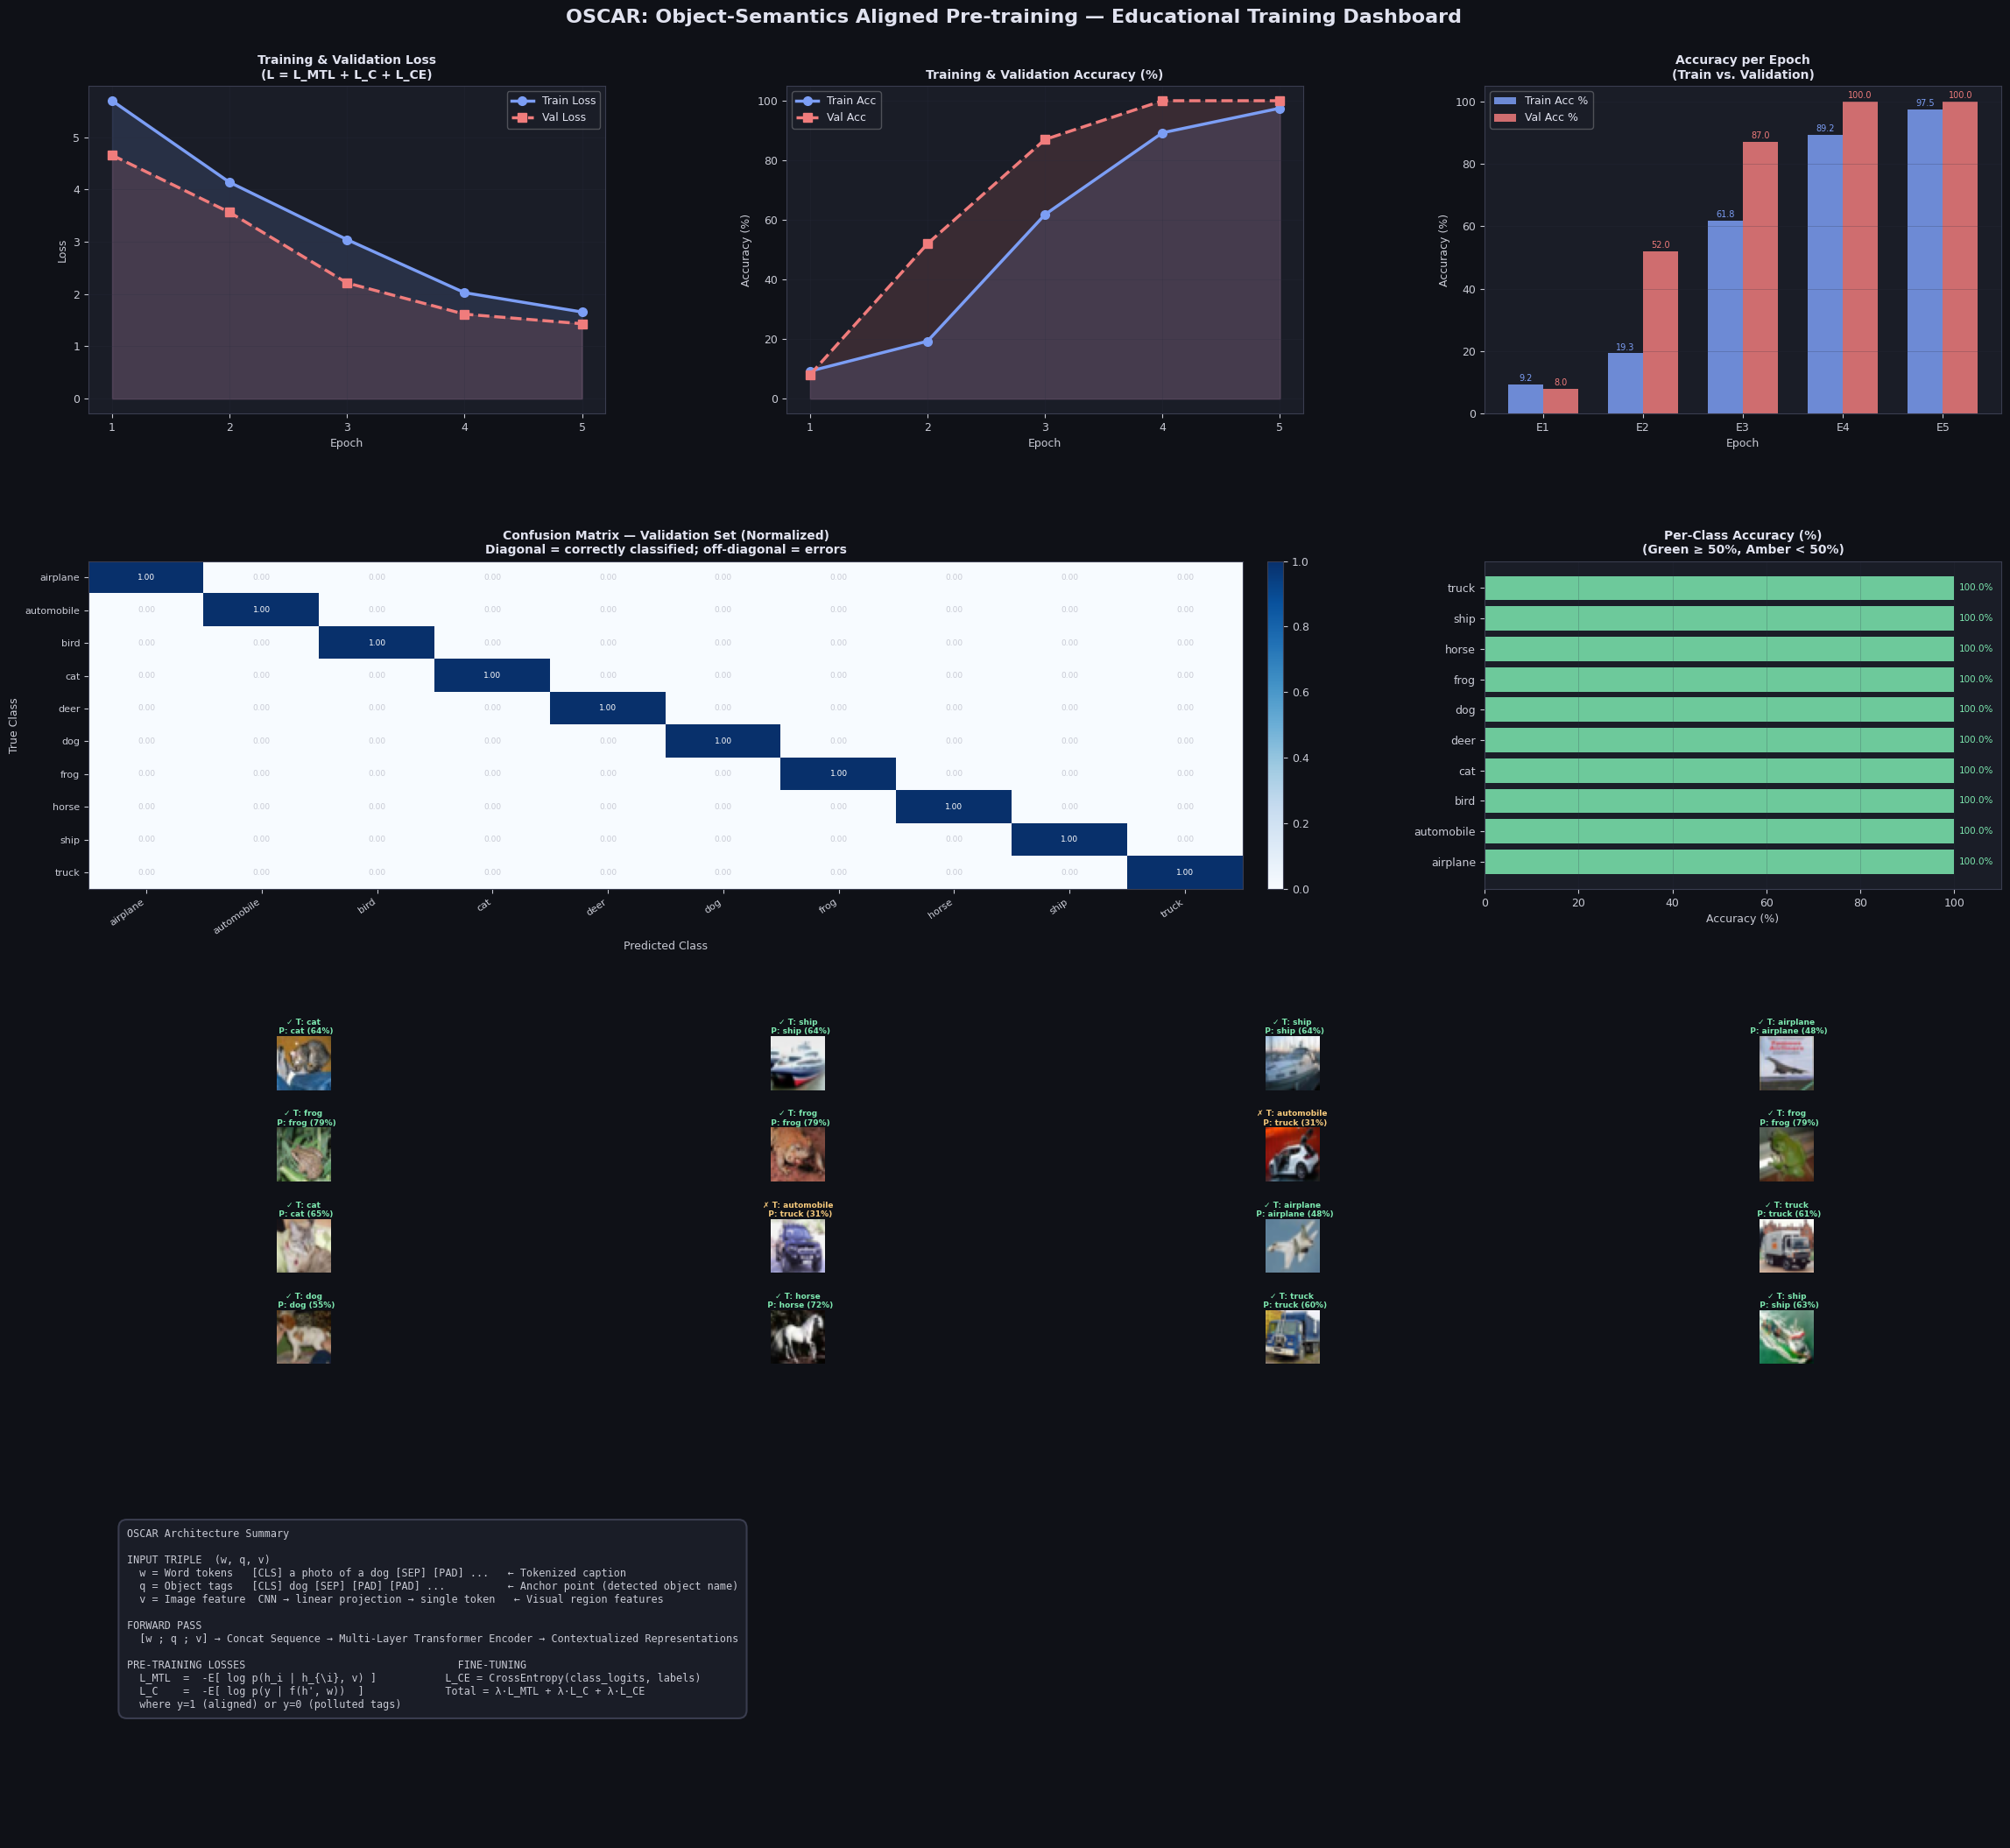


Dashboard saved to: oscar_dashboard.png
OSCAR Educational Implementation complete.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. COMPREHENSIVE DASHBOARD VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
# All key visuals are combined into a single dashboard figure

epochs_range = range(1, NUM_EPOCHS + 1)
cm           = confusion_matrix(final_labels, final_preds)

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'  : 'DejaVu Sans',
    'font.size'    : 9,
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
    'figure.facecolor': '#0f1117',
    'axes.facecolor'  : '#1a1d27',
    'axes.edgecolor'  : '#3a3d4f',
    'axes.labelcolor' : '#c8cad4',
    'xtick.color'     : '#c8cad4',
    'ytick.color'     : '#c8cad4',
    'text.color'      : '#e0e2ef',
    'grid.color'      : '#2a2d3f',
    'grid.linewidth'  : 0.5,
})

ACCENT1 = '#7c9ef5'   # blue   — training metrics
ACCENT2 = '#f07c7c'   # red    — validation metrics
ACCENT3 = '#7de8b0'   # green  — correct predictions
ACCENT4 = '#f5c97c'   # amber  — incorrect predictions

fig = plt.figure(figsize=(24, 22), facecolor='#0f1117')
fig.suptitle(
    'OSCAR: Object-Semantics Aligned Pre-training — Educational Training Dashboard',
    fontsize=16, fontweight='bold', color='#e0e2ef', y=0.98
)

# ── Grid Layout ─────────────────────────────────────────────────────────────
# Row 0 : title bar (thin)
# Row 1 : loss curve | accuracy curve | learning rate
# Row 2 : confusion matrix (large) | train/val comparison bar
# Row 3 : sample predictions (4 x 4 grid)
# Row 4 : architecture diagram

gs = gridspec.GridSpec(
    4, 3,
    figure=fig,
    hspace=0.45, wspace=0.35,
    top=0.94, bottom=0.03,
    left=0.06, right=0.97
)

# ── Panel 1: Training & Validation Loss ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_range, history['train_loss'], 'o-', color=ACCENT1,
         linewidth=2.5, markersize=7, label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   's--', color=ACCENT2,
         linewidth=2.5, markersize=7, label='Val Loss')
ax1.fill_between(epochs_range, history['train_loss'],
                 alpha=0.15, color=ACCENT1)
ax1.fill_between(epochs_range, history['val_loss'],
                 alpha=0.15, color=ACCENT2)
ax1.set_title('Training & Validation Loss\n(L = L_MTL + L_C + L_CE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(framealpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs_range)

# ── Panel 2: Training & Validation Accuracy ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
train_acc_pct = [a * 100 for a in history['train_acc']]
val_acc_pct   = [a * 100 for a in history['val_acc']]
ax2.plot(epochs_range, train_acc_pct, 'o-', color=ACCENT1,
         linewidth=2.5, markersize=7, label='Train Acc')
ax2.plot(epochs_range, val_acc_pct,   's--', color=ACCENT2,
         linewidth=2.5, markersize=7, label='Val Acc')
ax2.fill_between(epochs_range, train_acc_pct, alpha=0.15, color=ACCENT1)
ax2.fill_between(epochs_range, val_acc_pct,   alpha=0.15, color=ACCENT2)
ax2.set_title('Training & Validation Accuracy (%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend(framealpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs_range)

# ── Panel 3: Per-Epoch Metric Summary Bar ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
x     = np.arange(NUM_EPOCHS)
width = 0.35
bars1 = ax3.bar(x - width/2, train_acc_pct, width,
                label='Train Acc %', color=ACCENT1, alpha=0.85)
bars2 = ax3.bar(x + width/2, val_acc_pct,   width,
                label='Val Acc %',   color=ACCENT2, alpha=0.85)
ax3.set_title('Accuracy per Epoch\n(Train vs. Validation)')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy (%)')
ax3.set_xticks(x)
ax3.set_xticklabels([f'E{i+1}' for i in range(NUM_EPOCHS)])
ax3.legend(framealpha=0.3)
ax3.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}', ha='center', va='bottom',
             fontsize=7, color=ACCENT1)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}', ha='center', va='bottom',
             fontsize=7, color=ACCENT2)

# ── Panel 4: Confusion Matrix ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
im = ax4.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax4, fraction=0.03, pad=0.02)
ax4.set_xticks(range(NUM_CLASSES))
ax4.set_yticks(range(NUM_CLASSES))
ax4.set_xticklabels(CIFAR10_CLASSES, rotation=35, ha='right', fontsize=8)
ax4.set_yticklabels(CIFAR10_CLASSES, fontsize=8)
ax4.set_title('Confusion Matrix — Validation Set (Normalized)\n'
              'Diagonal = correctly classified; off-diagonal = errors')
ax4.set_xlabel('Predicted Class')
ax4.set_ylabel('True Class')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = cm_norm[i, j]
        ax4.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=6.5,
                 color='white' if val > 0.5 else '#c8cad4')

# ── Panel 5: Per-Class Accuracy Bar ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-9)
colors_bar    = [ACCENT3 if a >= 0.5 else ACCENT4 for a in per_class_acc]
bars          = ax5.barh(CIFAR10_CLASSES, per_class_acc * 100,
                         color=colors_bar, alpha=0.85)
ax5.set_title('Per-Class Accuracy (%)\n(Green ≥ 50%, Amber < 50%)')
ax5.set_xlabel('Accuracy (%)')
ax5.set_xlim(0, 110)
ax5.grid(True, alpha=0.3, axis='x')
for bar, acc in zip(bars, per_class_acc):
    ax5.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{acc*100:.1f}%', va='center', fontsize=7.5,
             color=ACCENT3 if acc >= 0.5 else ACCENT4)

# ── Panel 6: Sample Predictions (4 x 4) ──────────────────────────────────────
gs_inner = gridspec.GridSpecFromSubplotSpec(
    4, 4, subplot_spec=gs[2, :], hspace=0.7, wspace=0.15
)
for i in range(16):
    ax = fig.add_subplot(gs_inner[i // 4, i % 4])
    ax.imshow(sample_images[i])
    ax.axis('off')
    true_name = CIFAR10_CLASSES[sample_true[i]]
    pred_name = CIFAR10_CLASSES[sample_pred[i]]
    is_correct = sample_true[i] == sample_pred[i]
    color      = ACCENT3 if is_correct else ACCENT4
    tick       = '✓' if is_correct else '✗'
    ax.set_title(
        f'{tick} T: {true_name}\n  P: {pred_name} ({sample_conf[i]*100:.0f}%)',
        fontsize=6.5, color=color, pad=2
    )

# ── Panel 7: OSCAR Architecture Summary ───────────────────────────────────────
ax7 = fig.add_subplot(gs[3, :])
ax7.axis('off')
arch_text = (
    "OSCAR Architecture Summary\n\n"
    "INPUT TRIPLE  (w, q, v)\n"
    "  w = Word tokens   [CLS] a photo of a dog [SEP] [PAD] ...   ← Tokenized caption\n"
    "  q = Object tags   [CLS] dog [SEP] [PAD] [PAD] ...          ← Anchor point (detected object name)\n"
    "  v = Image feature  CNN → linear projection → single token   ← Visual region features\n\n"
    "FORWARD PASS\n"
    "  [w ; q ; v] → Concat Sequence → Multi-Layer Transformer Encoder → Contextualized Representations\n\n"
    "PRE-TRAINING LOSSES                                  FINE-TUNING\n"
    "  L_MTL  =  -E[ log p(h_i | h_{\\i}, v) ]           L_CE = CrossEntropy(class_logits, labels)\n"
    "  L_C    =  -E[ log p(y | f(h', w))  ]             Total = λ·L_MTL + λ·L_C + λ·L_CE\n"
    "  where y=1 (aligned) or y=0 (polluted tags)"
)
ax7.text(
    0.02, 0.95, arch_text,
    transform=ax7.transAxes,
    fontsize=8.5, verticalalignment='top',
    fontfamily='monospace',
    color='#c8cad4',
    bbox=dict(boxstyle='round,pad=0.8', facecolor='#1a1d27',
              edgecolor='#3a3d4f', linewidth=1.5)
)

plt.savefig('oscar_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("\nDashboard saved to: oscar_dashboard.png")
print("=" * 65)
print("OSCAR Educational Implementation complete.")

In [ ]:
# ============================================================
# OSCAR: Object-Semantics Aligned Pre-training
# Educational PyTorch Implementation on CIFAR-10 Subset
# ============================================================
# CORE PAPER IDEAS REPLICATED:
# 1. Triple input structure: (word tokens w, object tags q, image v)
#    — each sample is a (caption, anchor-tag, image-region) triple
# 2. Two-view perspective:
#    - Modality view  : [w | q,v]   text vs image
#    - Dictionary view: [w,q | v]   linguistic vs visual space
# 3. Masked Token Loss (MTL):
#    - Masks 15% of discrete tokens h=[w,q] jointly
#    - Model predicts masked token from context + full image
# 4. Contrastive Loss (CL):
#    - 50% chance: replace object tags q with random tags (polluted)
#    - Binary classifier on [CLS] predicts aligned (1) vs polluted (0)
# 5. Object tags as ANCHOR POINTS:
#    - Tags live in linguistic space → bridge to visual space
#    - Reduces weakly-supervised alignment to partially-supervised
# 6. Downstream classification head fine-tuned jointly
# ============================================================

# ── Standard Library ──────────────────────────────────────────
import math, random, warnings
import numpy as np
from collections import defaultdict
warnings.filterwarnings("ignore")

# ── PyTorch ───────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

# ── Torchvision ───────────────────────────────────────────────
import torchvision
import torchvision.transforms as transforms

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [ ]:
# ============================================================
# SECTION 0 — REPRODUCIBILITY & CONFIGURATION
# ============================================================

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Training Settings ─────────────────────────────────────────
NUM_EPOCHS   = 5
BATCH_SIZE   = 64
LR           = 3e-4
WEIGHT_DECAY = 1e-4
SUBSET_TRAIN = 2000
SUBSET_TEST  = 400
NUM_CLASSES  = 10

# ── CIFAR-10 ──────────────────────────────────────────────────
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird",  "cat",  "deer",
    "dog",      "frog",       "horse", "ship", "truck"
]

# ── Model Architecture ────────────────────────────────────────
D_MODEL    = 128     # shared embedding dimension (H in paper)
N_HEADS    = 4       # Transformer attention heads
N_LAYERS   = 2       # Transformer encoder layers
FF_DIM     = D_MODEL * 4
DROPOUT    = 0.1

# ── Tokenizer Settings ────────────────────────────────────────
MAX_SEQ_LEN = 14     # max discrete token length (h = [w, q])
MASK_PROB   = 0.15   # 15% masking rate — directly from paper
NEG_PROB    = 0.50   # 50% tag pollution rate — directly from paper

# ── Matplotlib Style ──────────────────────────────────────────
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "figure.dpi"       : 130,
})
CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

print(f"Device   : {DEVICE}")
print(f"D_MODEL  : {D_MODEL} | N_HEADS : {N_HEADS} | N_LAYERS : {N_LAYERS}")
print(f"Mask prob: {MASK_PROB} | Neg prob: {NEG_PROB}")


Device   : cuda
D_MODEL  : 128 | N_HEADS : 4 | N_LAYERS : 2
Mask prob: 0.15 | Neg prob: 0.5


In [ ]:
# ============================================================
# SECTION 1 — VOCABULARY & CAPTION SIMULATION
# ============================================================
# Real OSCAR: MS COCO captions + Faster R-CNN detected tags.
# Here: synthetic captions per class, class name = anchor tag.
# On MS COCO, ≥1 shared object between image & text: 49.7% pairs.

CAPTION_TEMPLATES = {
    "airplane"   : ["a photo of an airplane flying in the sky",
                    "an aircraft soaring above the clouds",
                    "a military airplane on a runway"],
    "automobile" : ["a photo of a car driving on the road",
                    "an automobile parked outside a building",
                    "a red sports car moving fast"],
    "bird"       : ["a photo of a bird perching on a branch",
                    "a small colorful bird in the wild",
                    "a bird flying over the trees"],
    "cat"        : ["a photo of a cat sitting on a couch",
                    "a fluffy cat looking at the camera",
                    "a cute cat resting on a bed"],
    "deer"       : ["a photo of a deer standing in a forest",
                    "a wild deer grazing in the grass",
                    "a deer running across an open field"],
    "dog"        : ["a photo of a dog running in a park",
                    "a playful dog sitting outside",
                    "a brown dog looking at its owner"],
    "frog"       : ["a photo of a frog sitting on a leaf",
                    "a green frog near a pond",
                    "a small frog in the grass"],
    "horse"      : ["a photo of a horse galloping in a field",
                    "a brown horse standing in a stable",
                    "a horse being ridden by a jockey"],
    "ship"       : ["a photo of a large ship at sea",
                    "a cargo vessel sailing on the ocean",
                    "a ship passing through a harbor"],
    "truck"      : ["a photo of a truck on a highway",
                    "a large cargo truck transporting goods",
                    "a red truck parked at a loading dock"],
}

# Special tokens mirror BERT's design (used in the OSCAR paper)
SPECIAL_TOKENS = ["[PAD]", "[CLS]", "[SEP]", "[MASK]", "[UNK]"]

def build_vocab():
    """Collect all unique words from captions and class names."""
    words = set(SPECIAL_TOKENS)
    for cls_name, caps in CAPTION_TEMPLATES.items():
        words.add(cls_name)
        for cap in caps:
            words.update(cap.lower().split())
    return {w: i for i, w in enumerate(sorted(words))}

VOCAB      = build_vocab()
VOCAB_SIZE = len(VOCAB)
PAD_ID     = VOCAB["[PAD]"]
CLS_ID     = VOCAB["[CLS]"]
SEP_ID     = VOCAB["[SEP]"]
MASK_ID    = VOCAB["[MASK]"]
UNK_ID     = VOCAB["[UNK]"]

def tokenize(text, max_len=MAX_SEQ_LEN):
    """
    Convert text → padded token-ID tensor.
    Format: [CLS] w1 w2 ... wN [SEP] [PAD] ...
    Mirrors BERT-style tokenization used in OSCAR.
    """
    ids = [CLS_ID]
    for w in text.lower().split():
        ids.append(VOCAB.get(w, UNK_ID))
    ids.append(SEP_ID)
    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))
    else:
        ids = ids[:max_len - 1] + [SEP_ID]
    return torch.tensor(ids, dtype=torch.long)

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Sample token IDs: {tokenize('a photo of a dog').tolist()}")

Vocabulary size : 93
Sample token IDs: [0, 5, 67, 57, 5, 30, 3, 2, 2, 2, 2, 2, 2, 2]


In [ ]:
# ============================================================
# SECTION 2 — OSCAR-STYLE TRIPLE DATASET
# ============================================================
# Each sample = (w, q, v) triple — core OSCAR input format.
#   w : word embeddings of caption text
#   q : word embeddings of object tags (anchor points)
#   v : image region features (CNN replaces Faster R-CNN)
#
# Key paper observation exploited here:
# "Salient objects in an image are often mentioned in paired text"
# → class name appears in both caption (w) AND tag (q)

class OSCARDataset(Dataset):
    """
    Wraps CIFAR-10 to produce OSCAR-style (w, q, v) triples.
    The object tag q is the class name — the anchor point
    that bridges the visual and linguistic semantic spaces.
    """
    def __init__(self, cifar_dataset):
        self.dataset = cifar_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        cls_name     = CIFAR10_CLASSES[label]

        # w: word tokens — randomized caption for variety
        caption      = random.choice(CAPTION_TEMPLATES[cls_name])
        word_tokens  = tokenize(caption)

        # q: object tag tokens — the ANCHOR POINT (paper's key idea)
        # In the paper: Faster R-CNN detection labels
        # Here: ground-truth class name (perfect anchor)
        tag_tokens   = tokenize(cls_name)

        return (image,
                word_tokens,
                tag_tokens,
                torch.tensor(label, dtype=torch.long))


# ── Data Loading ──────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

raw_train = torchvision.datasets.CIFAR10(
    "./data", train=True,  download=True, transform=transform)
raw_test  = torchvision.datasets.CIFAR10(
    "./data", train=False, download=True, transform=transform)

train_loader = DataLoader(
    OSCARDataset(Subset(raw_train, range(SUBSET_TRAIN))),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(
    OSCARDataset(Subset(raw_test, range(SUBSET_TEST))),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train : {SUBSET_TRAIN} | Test : {SUBSET_TEST}")
print(f"Train batches : {len(train_loader)} | "
      f"Test batches : {len(test_loader)}")

 17%|█▋        | 29.6M/170M [10:28<44:53, 52.3kB/s]

In [ ]:
# ============================================================
# SECTION 3 — MODEL BUILDING BLOCKS
# ============================================================

# ── 3.1 Image Encoder (replaces Faster R-CNN in paper) ────────
# Paper: Faster R-CNN → K region vectors v_k ∈ R^2048
#        then linear projection W to match BERT hidden size H
# Here:  small CNN → single feature vector ∈ R^D_MODEL
# The position-sensitive region feature: v = W · [v'; z]

class ImageEncoder(nn.Module):
    """
    CNN image encoder — educational surrogate for Faster R-CNN.

    Paper equation:
        v_k = W · [v'_k ; z_k]
    where v'_k ∈ R^2048 (appearance), z_k ∈ R^{4 or 6} (location).
    Here we output a single D_MODEL vector from the full image.
    """
    def __init__(self, d_model=D_MODEL):
        super().__init__()
        self.conv = nn.Sequential(
            # Block 1: 3×32×32 → 32×16×16
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.GELU(),
            nn.MaxPool2d(2),
            # Block 2: 32×16×16 → 64×8×8
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.MaxPool2d(2),
            # Block 3: 64×8×8 → 128×4×4
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.MaxPool2d(2),
        )
        # Linear projection W — paper's position-sensitive region feature
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, d_model),
            nn.LayerNorm(d_model),
        )

    def forward(self, x):
        # x: (B, 3, 32, 32) → (B, D_MODEL)
        return self.proj(self.conv(x))


# ── 3.2 Token Embedder ────────────────────────────────────────
# Paper: BERT-style token + position embeddings
# Used for both word tokens w and object tag tokens q

class TokenEmbedder(nn.Module):
    """
    Converts token IDs to dense embeddings with positional encoding.
    Used for both word tokens (w) and object tags (q) separately,
    since they share the same linguistic semantic space in OSCAR.
    """
    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model,
                                     padding_idx=PAD_ID)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.norm    = nn.LayerNorm(d_model)
        self.drop    = nn.Dropout(DROPOUT)

    def forward(self, ids):
        # ids: (B, L)
        B, L   = ids.shape
        pos    = torch.arange(L, device=ids.device).unsqueeze(0)
        return self.drop(self.norm(
            self.tok_emb(ids) + self.pos_emb(pos)))


# ── 3.3 OSCAR Transformer Encoder ────────────────────────────
# Paper: multi-layer Transformer with unrestricted self-attention
# over the concatenated triple [w ; q ; v] (all tokens attend to all)

class OSCARTransformerLayer(nn.Module):
    """
    Single Transformer encoder layer.
    Unrestricted self-attention over all three modality tokens:
    [word tokens | object tags | image region token]
    This is OSCAR's key mechanism — cross-modal attention via anchors.
    """
    def __init__(self, d_model, n_heads, ff_dim, dropout):
        super().__init__()
        self.attn  = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        # x: (B, L_total, D) — all tokens concatenated
        h, attn_w = self.attn(x, x, x,
                               key_padding_mask=key_padding_mask,
                               need_weights=True,
                               average_attn_weights=False)
        x = self.norm1(x + self.drop(h))
        x = self.norm2(x + self.ff(x))
        return x, attn_w

In [ ]:
# ============================================================
# SECTION 4 — FULL OSCAR MODEL
# ============================================================
# Architecture (Fig. 1 & 3 of paper):
#
#  Caption tokens w ──→ TokenEmbedder ──────────────────────┐
#  Object tag tokens q ──→ TokenEmbedder ──────────────────┤
#  Image v ──→ ImageEncoder → proj → unsqueeze ─────────────┘
#              ↓  Concat: [w_emb ; q_emb ; v_token]
#         N_LAYERS × OSCARTransformerLayer (full self-attn)
#              ↓
#  ┌───────────────────────────────────────────────────────┐
#  │ MTL head  : predict masked tokens in h=[w,q]         │
#  │ CL head   : aligned(1) vs polluted(0) on [CLS]       │
#  │ CLS head  : downstream classification                 │
#  └───────────────────────────────────────────────────────┘

class OSCARModel(nn.Module):
    """
    Simplified OSCAR: Object-Semantics Aligned Pre-training
    (Li et al., Microsoft Research — ECCV 2020).
    """
    def __init__(self):
        super().__init__()

        # ── Embedders for each component of the triple ────────
        self.word_emb  = TokenEmbedder(VOCAB_SIZE, D_MODEL, MAX_SEQ_LEN)
        self.tag_emb   = TokenEmbedder(VOCAB_SIZE, D_MODEL, MAX_SEQ_LEN)

        # ── Image Encoder: Faster R-CNN surrogate ─────────────
        self.img_enc   = ImageEncoder(D_MODEL)

        # ── Linear projection for image "region token" ─────────
        # Paper: W matrix projects position-sensitive region feature
        self.img_proj  = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL),
            nn.LayerNorm(D_MODEL),
        )

        # ── Shared Transformer Encoder ─────────────────────────
        # All three components (w, q, v) attend to each other freely
        self.layers = nn.ModuleList([
            OSCARTransformerLayer(D_MODEL, N_HEADS, FF_DIM, DROPOUT)
            for _ in range(N_LAYERS)
        ])

        # ── Pre-Training Head 1: Masked Token Loss (MTL) ──────
        # Dictionary view: h = [w, q] — predict masked tokens
        # L_MTL = -E log p(h_i | h_{\\i}, v)
        self.mtl_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL),
            nn.GELU(),
            nn.LayerNorm(D_MODEL),
            nn.Linear(D_MODEL, VOCAB_SIZE),
        )

        # ── Pre-Training Head 2: Contrastive Loss (CL) ────────
        # Modality view: f([CLS]) → binary aligned/polluted
        # L_C = -E log p(y | f(h', w))
        self.cl_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2),
            nn.GELU(),
            nn.Linear(D_MODEL // 2, 2),
        )

        # ── Downstream Head: Classification ───────────────────
        # Fine-tuning: [CLS] → class prediction
        self.cls_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL // 2, NUM_CLASSES),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.02)

    def forward(self, images, word_ids, tag_ids,
                return_pretrain=False, return_attn=False):
        """
        Forward pass — OSCAR triple (w, q, v).

        Args:
            images        : (B, 3, 32, 32)
            word_ids      : (B, L) — word tokens w (may contain [MASK])
            tag_ids       : (B, L) — tag tokens q  (may be polluted)
            return_pretrain: return MTL and CL logits
            return_attn   : return attention weights

        Returns:
            cls_logits    : (B, NUM_CLASSES) — downstream prediction
            mtl_logits    : (B, 2L, VOCAB_SIZE) — masked token predictions
            cl_logits     : (B, 2) — aligned vs polluted
            attn_weights  : list of attention tensors (optional)
        """
        B = images.size(0)
        L = word_ids.size(1)

        # ── Step 1: Embed all three modalities ────────────────
        # w_emb: word token embeddings
        w_emb = self.word_emb(word_ids)          # (B, L, D)
        # q_emb: object tag embeddings (ANCHOR POINTS)
        q_emb = self.tag_emb(tag_ids)            # (B, L, D)
        # v_tok: image feature as a single visual token
        v_feat = self.img_enc(images)             # (B, D)
        v_tok  = self.img_proj(v_feat).unsqueeze(1) # (B, 1, D)

        # ── Step 2: Concatenate into unified triple sequence ──
        # x = [w ; q ; v] — the Word-Tag-Image triple
        # This is OSCAR's core input: x = (w, q, v)
        x = torch.cat([w_emb, q_emb, v_tok], dim=1)
        # x: (B, 2L+1, D)

        # ── Step 3: Build padding mask ────────────────────────
        # PAD tokens in w and q should be ignored by attention
        pad_w   = (word_ids == PAD_ID)              # (B, L)
        pad_q   = (tag_ids  == PAD_ID)              # (B, L)
        pad_v   = torch.zeros(B, 1, dtype=torch.bool,
                              device=images.device)  # (B, 1)
        pad_mask = torch.cat([pad_w, pad_q, pad_v], dim=1)

        # ── Step 4: Transformer — all tokens attend to all ───
        all_attn = []
        for layer in self.layers:
            x, attn_w = layer(x, key_padding_mask=pad_mask)
            all_attn.append(attn_w)

        # ── Step 5: Extract per-component representations ────
        cls_repr = x[:, 0, :]          # [CLS] — global alignment token
        word_out = x[:, :L, :]         # word token outputs
        tag_out  = x[:, L:2*L, :]      # tag token outputs

        # Discrete token sequence h = [w, q] for MTL
        h_out    = torch.cat([word_out, tag_out], dim=1)  # (B, 2L, D)

        # ── Step 6: Task heads ────────────────────────────────
        cls_logits = self.cls_head(cls_repr)   # (B, NUM_CLASSES)

        mtl_logits = cl_logits = None
        if return_pretrain:
            # MTL: predict masked tokens in h = [w, q]
            mtl_logits = self.mtl_head(h_out)  # (B, 2L, VOCAB_SIZE)
            # CL: alignment classification on [CLS]
            cl_logits  = self.cl_head(cls_repr) # (B, 2)

        if return_attn:
            return cls_logits, mtl_logits, cl_logits, all_attn

        return cls_logits, mtl_logits, cl_logits, None

In [ ]:
# ============================================================
# SECTION 5 — LOSS FUNCTIONS
# ============================================================

def apply_mtl_masking(word_ids, tag_ids, mask_prob=MASK_PROB):
    """
    Masked Token Loss preparation — Section 3 of OSCAR paper.

    h = [w, q] — both word tokens AND tag tokens are maskable.
    15% of non-special tokens are replaced with [MASK].
    Model must recover them from: context h_{\\i} + full image v.

    L_MTL = -E_{(v,h)~D} log p(h_i | h_{\\i}, v)
    """
    def mask_seq(ids):
        labels  = ids.clone()
        mask    = torch.rand_like(ids, dtype=torch.float) < mask_prob
        special = ((ids == PAD_ID) | (ids == CLS_ID) | (ids == SEP_ID))
        mask[special] = False
        masked         = ids.clone()
        masked[mask]   = MASK_ID
        labels[~mask]  = -100      # CrossEntropy ignore_index
        return masked, labels

    masked_w, labels_w = mask_seq(word_ids)
    masked_q, labels_q = mask_seq(tag_ids)
    # h_labels = [labels_w ; labels_q] for joint discrete sequence
    h_labels = torch.cat([labels_w, labels_q], dim=1)
    return masked_w, masked_q, h_labels


def apply_cl_pollution(tag_ids, neg_prob=NEG_PROB):
    """
    Contrastive Loss preparation — Section 3 of OSCAR paper.

    With probability 50%, replace object tags q with a randomly
    sampled tag sequence from another sample in the batch.
    This creates "polluted" image representations h' = [q_tilde, v].

    Binary label: y=1 (original, aligned) or y=0 (polluted).

    L_C = -E_{(h',w)~D} log p(y | f(h', w))
    """
    B = tag_ids.size(0)
    polluted   = tag_ids.clone()
    is_aligned = torch.ones(B, dtype=torch.long,
                            device=tag_ids.device)
    for i in range(B):
        if random.random() < neg_prob:
            j = random.choice([k for k in range(B) if k != i])
            polluted[i]   = tag_ids[j]
            is_aligned[i] = 0      # y=0: polluted
    return polluted, is_aligned


def compute_oscar_loss(cls_logits, labels,
                        mtl_logits, h_labels,
                        cl_logits,  is_aligned,
                        w_cls=1.0, w_mtl=0.5, w_cl=0.5):
    """
    Total OSCAR pre-training + downstream loss.

    Paper:  L_pre = L_MTL + L_C    (equal weights)
    Here:   L = w_cls*L_CE + w_mtl*L_MTL + w_cl*L_CL

    L_MTL: CrossEntropy over masked token predictions
    L_CL : Binary CrossEntropy for alignment discrimination
    L_CE : Downstream classification loss
    """
    # Downstream classification
    loss_cls = F.cross_entropy(cls_logits, labels)

    # L_MTL: predict masked tokens in h = [w, q]
    loss_mtl = F.cross_entropy(
        mtl_logits.view(-1, VOCAB_SIZE),
        h_labels.view(-1),
        ignore_index=-100)

    # L_CL: aligned vs polluted binary classification
    loss_cl = F.cross_entropy(cl_logits, is_aligned)

    total = w_cls * loss_cls + w_mtl * loss_mtl + w_cl * loss_cl
    return total, loss_cls, loss_mtl, loss_cl

In [ ]:
# ============================================================
# SECTION 6 — MODEL, OPTIMIZER & SCHEDULER
# ============================================================

model     = OSCARModel().to(DEVICE)
optimizer = optim.AdamW(model.parameters(),
                        lr=LR,
                        betas=(0.9, 0.999),
                        weight_decay=WEIGHT_DECAY)

# Linear warmup then cosine decay (similar to OSCAR's training)
total_steps  = (SUBSET_TRAIN // BATCH_SIZE) * NUM_EPOCHS
warmup_steps = max(1, int(0.10 * total_steps))

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / warmup_steps
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * prog))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

n_params = sum(p.numel() for p in model.parameters()
               if p.requires_grad)
print(f"Trainable parameters : {n_params:,}")
print(f"Total / Warmup steps : {total_steps} / {warmup_steps}")

In [ ]:
# ============================================================
# SECTION 7 — TRAINING & EVALUATION FUNCTIONS
# ============================================================

def train_one_epoch(loader):
    """
    Single training epoch with all OSCAR pre-training objectives.

    Each batch:
      1. Apply MTL masking to h = [w, q]          (15% mask)
      2. Apply CL pollution to q                   (50% pollute)
      3. Forward pass → cls, mtl, cl logits
      4. Compute L = L_CE + L_MTL + L_CL
      5. Backward + gradient clip + step
    """
    model.train()
    sums    = defaultdict(float)
    correct = n_total = 0

    for imgs, word_ids, tag_ids, labels in loader:
        imgs     = imgs.to(DEVICE)
        word_ids = word_ids.to(DEVICE)
        tag_ids  = tag_ids.to(DEVICE)
        labels   = labels.to(DEVICE)

        # Step 1: Mask tokens for MTL (h = [w, q])
        masked_w, masked_q, h_labels = apply_mtl_masking(
            word_ids, tag_ids)

        # Step 2: Pollute tags for CL
        polluted_q, is_aligned = apply_cl_pollution(masked_q)

        # Step 3: Forward — return pre-training outputs
        cls_logits, mtl_logits, cl_logits, _ = model(
            imgs, masked_w, polluted_q,
            return_pretrain=True)

        # Step 4: Compute combined OSCAR loss
        (loss, loss_cls,
         loss_mtl, loss_cl) = compute_oscar_loss(
            cls_logits, labels,
            mtl_logits, h_labels,
            cl_logits,  is_aligned)

        # Step 5: Backward
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        preds = cls_logits.argmax(1)
        bs    = imgs.size(0)
        sums["total"] += loss.item()     * bs
        sums["cls"]   += loss_cls.item() * bs
        sums["mtl"]   += loss_mtl.item() * bs
        sums["cl"]    += loss_cl.item()  * bs
        correct       += (preds == labels).sum().item()
        n_total       += bs

    return ({k: v / n_total for k, v in sums.items()},
            correct / n_total)


def evaluate(loader):
    """
    Evaluation on test set.
    Uses CLEAN (unmasked, un-polluted) tokens — no masking at test time.
    Returns losses, accuracy, predictions, and sample data.
    """
    model.eval()
    sums    = defaultdict(float)
    correct = n_total = 0
    all_preds, all_labels = [], []
    s_imgs, s_preds, s_lbls, s_confs = [], [], [], []
    last_attn = None

    with torch.no_grad():
        for imgs, word_ids, tag_ids, labels in loader:
            imgs     = imgs.to(DEVICE)
            word_ids = word_ids.to(DEVICE)
            tag_ids  = tag_ids.to(DEVICE)
            labels   = labels.to(DEVICE)

            # Clean forward — no masking or pollution at eval
            cls_logits, mtl_logits, cl_logits, attn_w = model(
                imgs, word_ids, tag_ids,
                return_pretrain=True, return_attn=True)

            # Dummy targets for loss logging at eval
            h_labels_dummy = torch.full(
                (imgs.size(0), 2 * MAX_SEQ_LEN), -100,
                dtype=torch.long, device=DEVICE)
            is_aligned_dummy = torch.ones(
                imgs.size(0), dtype=torch.long, device=DEVICE)

            (loss, loss_cls,
             loss_mtl, loss_cl) = compute_oscar_loss(
                cls_logits, labels,
                mtl_logits, h_labels_dummy,
                cl_logits,  is_aligned_dummy)

            probs  = F.softmax(cls_logits, 1)
            preds  = probs.argmax(1)
            confs  = probs.max(1).values

            bs = imgs.size(0)
            sums["total"] += loss.item()     * bs
            sums["cls"]   += loss_cls.item() * bs
            sums["mtl"]   += loss_mtl.item() * bs
            sums["cl"]    += loss_cl.item()  * bs
            correct       += (preds == labels).sum().item()
            n_total       += bs
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            last_attn = attn_w

            if len(s_imgs) < 32:
                s_imgs.extend(imgs.cpu())
                s_preds.extend(preds.cpu().tolist())
                s_lbls.extend(labels.cpu().tolist())
                s_confs.extend(confs.cpu().tolist())

    return ({k: v / n_total for k, v in sums.items()},
            correct / n_total,
            all_preds, all_labels,
            s_imgs[:32], s_preds[:32],
            s_lbls[:32], s_confs[:32],
            last_attn)

In [ ]:
# ============================================================
# SECTION 8 — TRAINING LOOP (5 EPOCHS)
# ============================================================

history = defaultdict(list)

header = (f"{'Ep':>3} {'Total':>8} {'CLS':>7} "
          f"{'MTL':>7} {'CL':>7} "
          f"{'TrAcc':>7} {'VaLoss':>8} {'VaAcc':>7}")
print("\n" + header)
print("-" * len(header))

for epoch in range(1, NUM_EPOCHS + 1):
    tr_losses, tr_acc = train_one_epoch(train_loader)
    (va_losses, va_acc,
     v_preds, v_lbls,
     s_imgs, s_preds,
     s_lbls, s_confs,
     last_attn) = evaluate(test_loader)

    for k in tr_losses:
        history[f"tr_{k}"].append(tr_losses[k])
    history["tr_acc"].append(tr_acc * 100)
    history["va_total"].append(va_losses["total"])
    history["va_acc"].append(va_acc * 100)
    history["v_preds"].append(v_preds)
    history["v_lbls"].append(v_lbls)

    print(f"{epoch:>3} "
          f"{tr_losses['total']:>8.4f} "
          f"{tr_losses['cls']:>7.4f} "
          f"{tr_losses['mtl']:>7.4f} "
          f"{tr_losses['cl']:>7.4f} "
          f"{tr_acc*100:>6.2f}% "
          f"{va_losses['total']:>8.4f} "
          f"{va_acc*100:>6.2f}%")

final_preds  = history["v_preds"][-1]
final_labels = history["v_lbls"][-1]
cm           = confusion_matrix(final_labels, final_preds)
per_cls_acc  = [100 * cm[c, c] / cm[c].sum()
                if cm[c].sum() else 0.0
                for c in range(NUM_CLASSES)]

print("\nTraining complete.")

In [ ]:
# ============================================================
# SECTION 9 — VISUALIZATION UTILITIES
# ============================================================

MEAN_T = torch.tensor(CIFAR_MEAN)
STD_T  = torch.tensor(CIFAR_STD)

def denorm(t):
    x = t.clone()
    for c in range(3):
        x[c] = x[c] * STD_T[c] + MEAN_T[c]
    return x.clamp(0, 1)

epochs_x = list(range(1, NUM_EPOCHS + 1))

# Epoch-wise per-class accuracy matrix
epoch_cls_acc = np.zeros((NUM_EPOCHS, NUM_CLASSES))
for ep in range(NUM_EPOCHS):
    cm_ep = confusion_matrix(
        history["v_lbls"][ep], history["v_preds"][ep],
        labels=list(range(NUM_CLASSES)))
    for c in range(NUM_CLASSES):
        if cm_ep[c].sum():
            epoch_cls_acc[ep, c] = (
                100 * cm_ep[c, c] / cm_ep[c].sum())

In [ ]:
# ============================================================
# VISUALIZATION 1 — LOSS DECOMPOSITION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("OSCAR — Training Loss Decomposition by Task",
             fontsize=14, fontweight="bold")
axes = axes.flat

task_specs = [
    ("tr_total", "va_total", "Total Loss",
     "#1565C0", "#C62828"),
    ("tr_cls",   None,       "CLS Downstream Loss",
     "#2E7D32", None),
    ("tr_mtl",   None,
     "MTL Loss (L_MTL = -E log p(h_i | h_{{\\i}}, v))",
     "#6A1B9A", None),
    ("tr_cl",    None,
     "CL Loss (L_C = -E log p(y | f(h', w)))",
     "#E65100", None),
]

for ax, (tr_k, va_k, title, tc, vc) in zip(axes, task_specs):
    ax.plot(epochs_x, history[tr_k], "o-",
            color=tc, lw=2.5, label="Train")
    if va_k:
        ax.plot(epochs_x, history[va_k], "s--",
                color=vc, lw=2.5, label="Val")
    for i, v in enumerate(history[tr_k]):
        ax.annotate(f"{v:.3f}", (epochs_x[i], v),
                    xytext=(0, 8), textcoords="offset points",
                    fontsize=7.5, color=tc, ha="center")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_xticks(epochs_x); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("oscar_viz1_losses.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# VISUALIZATION 2 — ACCURACY CURVES
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("OSCAR — Training vs Validation Accuracy",
             fontsize=14, fontweight="bold")
ax.plot(epochs_x, history["tr_acc"], "o-",
        color="#2E7D32", lw=2.5, label="Train Accuracy")
ax.plot(epochs_x, history["va_acc"], "s--",
        color="#E65100", lw=2.5, label="Val Accuracy")
ax.axhline(10, color="gray", ls=":", lw=1.2,
           label="Random baseline (10%)")
ax.fill_between(epochs_x, history["tr_acc"],
                history["va_acc"], alpha=0.08, color="gray")
for i, (ta, va) in enumerate(
        zip(history["tr_acc"], history["va_acc"])):
    ax.annotate(f"{ta:.1f}%", (epochs_x[i], ta),
                xytext=(0, 9), textcoords="offset points",
                fontsize=8, color="#2E7D32", ha="center")
    ax.annotate(f"{va:.1f}%", (epochs_x[i], va),
                xytext=(0, -15), textcoords="offset points",
                fontsize=8, color="#E65100", ha="center")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_xticks(epochs_x); ax.set_ylim(0, 110)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("oscar_viz2_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# VISUALIZATION 3 — CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("OSCAR — Confusion Matrix Analysis",
             fontsize=14, fontweight="bold")

cmap_b = LinearSegmentedColormap.from_list(
    "bw", ["#FFFFFF", "#0D47A1"])
cmap_g = LinearSegmentedColormap.from_list(
    "gw", ["#FFFFFF", "#1B5E20"])

sns.heatmap(cm, annot=True, fmt="d", cmap=cmap_b,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            linewidths=0.4, linecolor="lightgray",
            cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title("Raw Counts", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=40)

cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap=cmap_g,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            linewidths=0.4, linecolor="lightgray",
            cbar_kws={"shrink": 0.8}, vmin=0, vmax=1,
            ax=axes[1])
axes[1].set_title("Normalized (Recall per Class)",
                  fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("oscar_viz3_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# VISUALIZATION 4 — SAMPLE PREDICTIONS GRID
# ============================================================

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle(
    "OSCAR Sample Predictions  |  Green = Correct  |  "
    "Red = Wrong  |  Confidence shown",
    fontsize=12, fontweight="bold")

for idx, ax in enumerate(axes.flat):
    if idx >= len(s_imgs):
        ax.axis("off"); continue
    ax.imshow(denorm(s_imgs[idx]).permute(1, 2, 0).numpy(),
              interpolation="bilinear")
    ax.axis("off")
    correct = (s_lbls[idx] == s_preds[idx])
    col = "#1B5E20" if correct else "#B71C1C"
    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(col)
        ax.spines[spine].set_linewidth(3)
    ax.set_title(
        f"T:{CIFAR10_CLASSES[s_lbls[idx]][:4]}\n"
        f"P:{CIFAR10_CLASSES[s_preds[idx]][:4]} "
        f"({s_confs[idx]*100:.0f}%)",
        fontsize=6.5, color=col, pad=3)

plt.tight_layout()
plt.savefig("oscar_viz4_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# VISUALIZATION 5 — ANCHOR POINT ANALYSIS
# ============================================================
# Unique to OSCAR: visualize how object tag tokens in the
# triple input compare to the word tokens in caption.
# This demonstrates the "anchor" mechanism from the paper.

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(
    "OSCAR Anchor Point Visualization\n"
    "(Object tags q bridge the visual and linguistic spaces)",
    fontsize=13, fontweight="bold")

# Panel A: token mask pattern (MTL — both w and q maskable)
ax = axes[0]
example_cls  = 3   # "cat"
cap          = CAPTION_TEMPLATES[CIFAR10_CLASSES[example_cls]][0]
word_toks    = tokenize(cap)
tag_toks     = tokenize(CIFAR10_CLASSES[example_cls])
masked_w, masked_q, _ = apply_mtl_masking(
    word_toks.unsqueeze(0), tag_toks.unsqueeze(0))
masked_w = masked_w.squeeze(0)
masked_q = masked_q.squeeze(0)

total_len = 2 * MAX_SEQ_LEN
colors_a  = []
labels_a  = []
for i in range(MAX_SEQ_LEN):
    if masked_w[i] == MASK_ID:
        colors_a.append("#6A1B9A")   # masked word
    elif word_toks[i] == PAD_ID:
        colors_a.append("#ECEFF1")
    else:
        colors_a.append("#1565C0")   # visible word
    labels_a.append(f"w{i}")

for i in range(MAX_SEQ_LEN):
    if masked_q[i] == MASK_ID:
        colors_a.append("#AD1457")   # masked tag
    elif tag_toks[i] == PAD_ID:
        colors_a.append("#ECEFF1")
    else:
        colors_a.append("#E65100")   # visible tag (anchor)
    labels_a.append(f"q{i}")

ax.bar(range(total_len), [1] * total_len,
       color=colors_a, edgecolor="black", lw=0.4)
ax.axvline(MAX_SEQ_LEN - 0.5, color="black", ls="--", lw=1.5)
ax.set_xticks(range(total_len))
ax.set_xticklabels(labels_a, rotation=55, fontsize=7)
ax.text(MAX_SEQ_LEN/2 - 0.5, 0.5, "WORD TOKENS w",
        ha="center", va="center", fontsize=9,
        fontweight="bold", color="white")
ax.text(MAX_SEQ_LEN + MAX_SEQ_LEN/2 - 0.5, 0.5,
        "OBJECT TAG TOKENS q\n(Anchor Points)",
        ha="center", va="center", fontsize=9,
        fontweight="bold", color="white")
ax.set_yticks([])

legend_els = [
    mpatches.Patch(color="#1565C0", label="Visible word token"),
    mpatches.Patch(color="#6A1B9A", label="Masked word [MASK]"),
    mpatches.Patch(color="#E65100", label="Visible tag (anchor)"),
    mpatches.Patch(color="#AD1457", label="Masked tag [MASK]"),
    mpatches.Patch(color="#ECEFF1", label="[PAD]"),
]
ax.legend(handles=legend_els, fontsize=7.5, loc="upper right")
ax.set_title(
    f'A. MTL Masking on h=[w,q]  |  Class: '
    f'"{CIFAR10_CLASSES[example_cls]}"\n'
    f'Caption: "{cap}"',
    fontweight="bold")

# Panel B: CL pollution illustration
ax = axes[1]
B_demo = 8
x_pos  = range(B_demo)
polluted_q_demo, is_aligned_demo = apply_cl_pollution(
    tag_toks.unsqueeze(0).expand(B_demo, -1).clone())
bar_cols = ["#2E7D32" if y == 1 else "#C62828"
            for y in is_aligned_demo.tolist()]
ax.bar(x_pos, [1] * B_demo, color=bar_cols,
       edgecolor="black", lw=0.7, width=0.6)
for i, (col, y) in enumerate(zip(bar_cols, is_aligned_demo.tolist())):
    label = "Aligned\ny=1" if y == 1 else "Polluted\ny=0"
    ax.text(i, 0.5, label, ha="center", va="center",
            fontsize=8, fontweight="bold", color="white")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"Sample {i+1}" for i in x_pos],
                   rotation=30, fontsize=8)
ax.set_yticks([])
ax.set_title(
    "B. CL Pollution — Contrastive Loss\n"
    "(Green=original tags aligned | Red=polluted tags y=0)",
    fontweight="bold")
legend_el2 = [
    mpatches.Patch(color="#2E7D32", label="Original tags (y=1)"),
    mpatches.Patch(color="#C62828", label="Polluted tags (y=0)"),
]
ax.legend(handles=legend_el2, fontsize=8)

plt.tight_layout()
plt.savefig("oscar_viz5_anchor.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# VISUALIZATION 6 — EPOCH-WISE CLASS ACCURACY HEATMAP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle("OSCAR — Epoch-wise Learning Dynamics",
             fontsize=14, fontweight="bold")

sns.heatmap(epoch_cls_acc,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=[f"Epoch {e}"
                         for e in range(1, NUM_EPOCHS+1)],
            annot=True, fmt=".1f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Acc (%)", "shrink": 0.8},
            ax=axes[0])
axes[0].set_title("Per-Class Accuracy per Epoch")
axes[0].tick_params(axis="x", rotation=35)

ax = axes[1]
for c in range(NUM_CLASSES):
    ax.plot(range(1, NUM_EPOCHS+1), epoch_cls_acc[:, c],
            "o-", lw=1.8, color=CLASS_COLORS[c],
            label=CIFAR10_CLASSES[c], alpha=0.85)
ax.axhline(10, color="gray", ls=":", lw=1, label="Random")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy Trajectories")
ax.set_xticks(range(1, NUM_EPOCHS+1))
ax.legend(fontsize=7, ncol=2); ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("oscar_viz6_epoch_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# VISUALIZATION 7 — PER-CLASS PERFORMANCE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("OSCAR — Per-Class Performance",
             fontsize=14, fontweight="bold")

ax = axes[0]
brs = ax.bar(CIFAR10_CLASSES, per_cls_acc,
             color=CLASS_COLORS, edgecolor="black", lw=0.7)
ax.axhline(np.mean(per_cls_acc), color="red", ls="-.", lw=1.5,
           label=f"Mean {np.mean(per_cls_acc):.1f}%")
ax.axhline(10, color="navy", ls=":", lw=1.2,
           label="Random (10%)")
for b, a in zip(brs, per_cls_acc):
    ax.text(b.get_x() + b.get_width()/2, a + 1.2,
            f"{a:.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold")
ax.set_ylim(0, 115); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy"); ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
support = [cm[c].sum() for c in range(NUM_CLASSES)]
ax.bar(CIFAR10_CLASSES, support,
       color=CLASS_COLORS, edgecolor="black", lw=0.7)
for i, s in enumerate(support):
    ax.text(i, s + 0.5, str(s),
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("# Test Samples")
ax.set_title("Class Support in Test Set")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("oscar_viz7_perclass.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# VISUALIZATION 8 — CROSS-MODAL ATTENTION HEATMAP
# ============================================================
# Visualize how word tokens w, tag tokens q, and image token v
# attend to each other — the core of OSCAR's anchor mechanism.

model.eval()
with torch.no_grad():
    s_img   = s_imgs[0].unsqueeze(0).to(DEVICE)
    s_label = s_lbls[0]
    s_wtok  = tokenize(
        random.choice(CAPTION_TEMPLATES[CIFAR10_CLASSES[s_label]])
    ).unsqueeze(0).to(DEVICE)
    s_qtok  = tokenize(
        CIFAR10_CLASSES[s_label]
    ).unsqueeze(0).to(DEVICE)
    (_, _, _, attn_all) = model(
        s_img, s_wtok, s_qtok,
        return_attn=True, return_pretrain=False)

last_attn_avg = attn_all[-1][0].mean(0).cpu().numpy()

# Build sequence labels: [w_0..w_L-1, q_0..q_L-1, v_img]
w_words = ([CIFAR10_CLASSES[s_label]] +
            random.choice(
                CAPTION_TEMPLATES[CIFAR10_CLASSES[s_label]]
            ).split())[:MAX_SEQ_LEN]
w_words  = (w_words + [""] * MAX_SEQ_LEN)[:MAX_SEQ_LEN]
q_word   = [CIFAR10_CLASSES[s_label]] + [""] * (MAX_SEQ_LEN - 1)
all_seq  = (["w:" + t for t in w_words] +
            ["q:" + t for t in q_word] +
            ["[IMG]"])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    f"OSCAR Cross-Modal Attention — Last Layer\n"
    f"Class: {CIFAR10_CLASSES[s_label].upper()}  "
    f"(q = object anchor tags; w = caption words; IMG = visual token)",
    fontsize=11, fontweight="bold")

ax = axes[0]
sns.heatmap(last_attn_avg, cmap="YlOrBr",
            xticklabels=all_seq,
            yticklabels=all_seq,
            ax=ax, cbar_kws={"shrink": 0.8},
            linewidths=0.2, linecolor="white")
ax.set_title("Full Self-Attention Matrix\n"
             "(Red = w→q anchor attention block)")
ax.tick_params(axis="x", rotation=55, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
# Highlight the w → q attention block
ax.add_patch(mpatches.Rectangle(
    (MAX_SEQ_LEN, 0), MAX_SEQ_LEN, MAX_SEQ_LEN,
    fill=False, edgecolor="red", lw=2.5, zorder=5))
ax.text(MAX_SEQ_LEN + MAX_SEQ_LEN/2, -1.0,
        "w → q (anchor)",
        ha="center", color="red",
        fontsize=9, fontweight="bold")

ax = axes[1]
word2tag = last_attn_avg[:MAX_SEQ_LEN, MAX_SEQ_LEN:2*MAX_SEQ_LEN]
sns.heatmap(word2tag, cmap="Reds",
            xticklabels=q_word,
            yticklabels=w_words,
            ax=ax, annot=True, fmt=".2f",
            cbar_kws={"shrink": 0.8},
            linewidths=0.3, linecolor="white")
ax.set_title("Word Token → Object Tag Attention\n"
             "(OSCAR anchor alignment signal)")
ax.set_xlabel("Object Tag Tokens q (Anchor)")
ax.set_ylabel("Caption Word Tokens w")
ax.tick_params(axis="x", rotation=35, labelsize=8)

plt.tight_layout()
plt.savefig("oscar_viz8_attention.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# VISUALIZATION 9 — CONFIDENCE ANALYSIS
# ============================================================

model.eval()
confs_correct, confs_wrong = [], []
probs_matrix = np.zeros((SUBSET_TEST, NUM_CLASSES))
ptr = 0

with torch.no_grad():
    for imgs, word_ids, tag_ids, labels in test_loader:
        imgs     = imgs.to(DEVICE)
        word_ids = word_ids.to(DEVICE)
        tag_ids  = tag_ids.to(DEVICE)
        cls_logits, _, _, _ = model(imgs, word_ids, tag_ids)
        probs  = F.softmax(cls_logits, 1).cpu().numpy()
        preds  = probs.argmax(1)
        bs     = imgs.size(0)
        probs_matrix[ptr:ptr+bs] = probs
        ptr += bs
        for i in range(bs):
            conf = probs[i].max()
            if preds[i] == labels[i].item():
                confs_correct.append(conf)
            else:
                confs_wrong.append(conf)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("OSCAR — Confidence Analysis",
             fontsize=14, fontweight="bold")

ax = axes[0]
ax.hist(confs_correct, bins=18, color="#2E7D32", alpha=0.75,
        edgecolor="black", lw=0.4,
        label=f"Correct (n={len(confs_correct)})")
ax.hist(confs_wrong, bins=18, color="#C62828", alpha=0.75,
        edgecolor="black", lw=0.4,
        label=f"Wrong (n={len(confs_wrong)})")
ax.axvline(np.mean(confs_correct), color="#1B5E20",
           ls="--", lw=2,
           label=f"Mean correct {np.mean(confs_correct):.2f}")
ax.axvline(np.mean(confs_wrong) if confs_wrong else 0,
           color="#B71C1C", ls="--", lw=2,
           label=f"Mean wrong "
                 f"{np.mean(confs_wrong) if confs_wrong else 0:.2f}")
ax.set_title("Confidence Distribution")
ax.legend(fontsize=7.5)

ax = axes[1]
box_data = [
    probs_matrix[
        [i for i, l in enumerate(final_labels) if l == c], c
    ].tolist()
    for c in range(NUM_CLASSES)
]
bp = ax.boxplot(box_data, patch_artist=True,
                medianprops=dict(color="black", lw=2))
for patch, col in zip(bp["boxes"], CLASS_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=35, fontsize=8)
ax.set_title("Class Probability Boxplots")
ax.axhline(0.1, color="navy", ls=":", lw=1.2)

ax = axes[2]
all_confs_a = probs_matrix.max(1)
all_correct = (probs_matrix.argmax(1) ==
               np.array(final_labels)).astype(float)
bins_conf   = np.linspace(0, 1, 11)
bin_acc, bin_conf_means = [], []
for lo, hi in zip(bins_conf[:-1], bins_conf[1:]):
    mask = (all_confs_a >= lo) & (all_confs_a < hi)
    if mask.sum():
        bin_acc.append(all_correct[mask].mean())
        bin_conf_means.append(all_confs_a[mask].mean())
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect")
ax.scatter(bin_conf_means, bin_acc, s=80, zorder=5,
           edgecolors="black", lw=0.5)
ax.fill_between(bin_conf_means, bin_acc, bin_conf_means,
                alpha=0.15, color="red",
                label="Calibration gap")
ax.set_title("Calibration Curve")
ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("oscar_viz9_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# VISUALIZATION 10 — COMPLETE RESULTS DASHBOARD
# (Modeled after the UNITER dashboard style)
# ============================================================

fig = plt.figure(figsize=(26, 20))
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle(
    "OSCAR: Object-Semantics Aligned Pre-training — Complete Dashboard\n"
    f"CIFAR-10 Subset  |  {SUBSET_TRAIN} train / "
    f"{SUBSET_TEST} test  |  {NUM_EPOCHS} epochs  |  "
    f"Device: {DEVICE}",
    fontsize=13, fontweight="bold", y=0.99)

gs = gridspec.GridSpec(3, 4, figure=fig,
                       hspace=0.48, wspace=0.38)

# ── A: Total Loss ─────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(epochs_x, history["tr_total"], "o-",
        color="#1565C0", lw=2, label="Train")
ax.plot(epochs_x, history["va_total"], "s--",
        color="#C62828", lw=2, label="Val")
for i, v in enumerate(history["tr_total"]):
    ax.annotate(f"{v:.3f}", (epochs_x[i], v),
                xytext=(0, 7), textcoords="offset points",
                fontsize=7, color="#1565C0", ha="center")
ax.set_title("A. Total Loss\n(L = L_CE + L_MTL + L_CL)",
             fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.legend(fontsize=8)

# ── B: Task Losses ────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.plot(epochs_x, history["tr_mtl"], "o-",
        color="#6A1B9A", lw=2, label="MTL (masked token)")
ax.plot(epochs_x, history["tr_cl"],  "s-",
        color="#E65100", lw=2, label="CL (contrastive)")
ax.plot(epochs_x, history["tr_cls"], "^-",
        color="#2E7D32", lw=2, label="CLS (classification)")
ax.set_title("B. Pre-Training Task Losses\n"
             "(MTL + CL + CLS downstream)",
             fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.legend(fontsize=7)

# ── C: Accuracy ───────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.plot(epochs_x, history["tr_acc"], "o-",
        color="#2E7D32", lw=2, label="Train")
ax.plot(epochs_x, history["va_acc"], "s--",
        color="#E65100", lw=2, label="Val")
ax.axhline(10, color="gray", ls=":", lw=1,
           label="Random (10%)")
for i, (ta, va) in enumerate(
        zip(history["tr_acc"], history["va_acc"])):
    ax.annotate(f"{ta:.1f}%", (epochs_x[i], ta),
                xytext=(0, 8), textcoords="offset points",
                fontsize=7, color="#2E7D32", ha="center")
    ax.annotate(f"{va:.1f}%", (epochs_x[i], va),
                xytext=(0, -14), textcoords="offset points",
                fontsize=7, color="#E65100", ha="center")
ax.set_title("C. Accuracy Curves", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.set_ylim(0, 105); ax.legend(fontsize=8)

# ── D: Per-Class Accuracy Bar ─────────────────────────────────
ax = fig.add_subplot(gs[0, 3])
brs = ax.bar(CIFAR10_CLASSES, per_cls_acc,
             color=CLASS_COLORS, edgecolor="black", lw=0.6)
ax.axhline(np.mean(per_cls_acc), color="red",
           ls="-.", lw=1.3,
           label=f"Mean {np.mean(per_cls_acc):.1f}%")
ax.set_ylim(0, 115)
ax.set_title("D. Per-Class Accuracy", fontweight="bold")
ax.tick_params(axis="x", rotation=40, labelsize=7)
ax.legend(fontsize=8)

# ── E: Confusion Matrix ───────────────────────────────────────
ax = fig.add_subplot(gs[1, :2])
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            cmap="Blues", vmin=0, vmax=1,
            linewidths=0.3, linecolor="lightgray",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("E. Normalized Confusion Matrix",
             fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=40, labelsize=8)

# ── F: Epoch-wise Accuracy Heatmap ───────────────────────────
ax = fig.add_subplot(gs[1, 2:])
sns.heatmap(epoch_cls_acc,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=[f"E{e}"
                         for e in range(1, NUM_EPOCHS+1)],
            annot=True, fmt=".0f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.4, linecolor="white",
            cbar_kws={"shrink": 0.7, "label": "%"},
            ax=ax)
ax.set_title("F. Per-Class Acc per Epoch",
             fontweight="bold")
ax.tick_params(axis="x", rotation=35, labelsize=8)

# ── G: Confidence Distribution ───────────────────────────────
ax = fig.add_subplot(gs[2, :2])
ax.hist(confs_correct, bins=18, color="#2E7D32", alpha=0.75,
        edgecolor="black", lw=0.4,
        label=f"Correct (n={len(confs_correct)})")
ax.hist(confs_wrong, bins=18, color="#C62828", alpha=0.75,
        edgecolor="black", lw=0.4,
        label=f"Wrong (n={len(confs_wrong)})")
ax.axvline(np.mean(confs_correct), color="#1B5E20",
           ls="--", lw=2)
if confs_wrong:
    ax.axvline(np.mean(confs_wrong), color="#B71C1C",
               ls="--", lw=2)
ax.set_title("G. Confidence Distribution",
             fontweight="bold")
ax.set_xlabel("Max Softmax Confidence")
ax.legend(fontsize=8)

# ── H: Summary Scorecard ─────────────────────────────────────
ax = fig.add_subplot(gs[2, 2:])
ax.axis("off")
best_ep  = history["va_acc"].index(max(history["va_acc"])) + 1
best_acc = max(history["va_acc"])
rows = [
    ("Metric",                  "Value"),
    ("─" * 24,                  "─" * 12),
    ("Best Val Accuracy",       f"{best_acc:.2f}%"),
    ("Best Epoch",              str(best_ep)),
    ("Final Total Loss",        f"{history['tr_total'][-1]:.4f}"),
    ("Final MTL Loss (L_MTL)",  f"{history['tr_mtl'][-1]:.4f}"),
    ("Final CL Loss  (L_C)",    f"{history['tr_cl'][-1]:.4f}"),
    ("Final CLS Loss",          f"{history['tr_cls'][-1]:.4f}"),
    ("Trainable Params",        f"{n_params:,}"),
    ("Vocab Size",              str(VOCAB_SIZE)),
    ("Mask Prob (paper: 15%)",  f"{MASK_PROB*100:.0f}%"),
    ("Poll Prob (paper: 50%)",  f"{NEG_PROB*100:.0f}%"),
    ("Top Class",
     f"{CIFAR10_CLASSES[int(np.argmax(per_cls_acc))]} "
     f"({max(per_cls_acc):.1f}%)"),
    ("Bottom Class",
     f"{CIFAR10_CLASSES[int(np.argmin(per_cls_acc))]} "
     f"({min(per_cls_acc):.1f}%)"),
    ("Mean Correct Conf",       f"{np.mean(confs_correct):.3f}"),
    ("Mean Wrong Conf",
     f"{np.mean(confs_wrong) if confs_wrong else 0:.3f}"),
    ("─" * 24,                  "─" * 12),
    ("Dataset",                 "CIFAR-10 Subset"),
    ("Train / Test",            f"{SUBSET_TRAIN} / {SUBSET_TEST}"),
    ("Epochs",                  str(NUM_EPOCHS)),
    ("Pre-training Tasks",      "MTL + CL (paper Eq. 2,3,4)"),
    ("Device",                  str(DEVICE)),
]
for row_i, (k, v) in enumerate(rows):
    wt  = "bold" if row_i in (0, 1) else "normal"
    col = "#1A237E" if row_i == 0 else "black"
    vc  = ("#B71C1C" if row_i == 2 else
           "#1B5E20" if row_i == 3 else "black")
    ax.text(0.02, 1 - row_i * 0.048, k,
            transform=ax.transAxes, fontsize=8.2,
            fontweight=wt, color=col, va="top")
    ax.text(0.55, 1 - row_i * 0.048, v,
            transform=ax.transAxes, fontsize=8.2,
            color=vc, va="top")
ax.set_title("H. Summary Scorecard", fontweight="bold")
ax.add_patch(mpatches.FancyBboxPatch(
    (0, 0), 1, 1,
    boxstyle="round,pad=0.02",
    transform=ax.transAxes, lw=1.5,
    edgecolor="#90CAF9", facecolor="#E3F2FD", zorder=0))

plt.savefig("oscar_viz10_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("All 10 OSCAR visualizations saved.")
print("Dashboard saved to: oscar_viz10_dashboard.png")

# OSCAR — Related Work Reference Table

| # | Author(s) | Year | Title | Venue | Connection to This Paper |
|---|-----------|------|-------|-------|--------------------------|
| 1 | Vaswani et al. | 2017 | Attention Is All You Need | NeurIPS | Foundational Transformer architecture upon which all VLP methods including OSCAR are built; self-attention mechanism is the backbone of cross-modal representation learning. |
| 2 | Devlin et al. | 2019 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL | OSCAR is initialized from BERT weights; BERT's masked language modeling directly motivates the Masked Token Loss ($\mathcal{L}_{\text{MTL}}$); BERT defines the linguistic semantic space used as anchor space for object tags. |
| 3 | Lu et al. | 2019 | ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks | NeurIPS | Representative two-stream VLP baseline; exemplifies the brute-force self-attention alignment approach that OSCAR critiques and improves upon. |
| 4 | Tan & Bansal | 2019 | LXMERT: Learning Cross-Modality Encoder Representations from Transformers | EMNLP | Three-stream VLP baseline used as direct performance comparison on VQA and other benchmarks; represents the prior large-model SoTA that OSCAR surpasses. |
| 5 | Chen et al. | 2019 | UNITER: Learning Universal Image-Text Representations | arXiv | Primary large-model SoTA baseline against which OSCAR is benchmarked across all tasks; the only comparable BERT-large scale VLP model evaluated in the paper. |
| 6 | Su et al. | 2019 | VL-BERT: Pre-training of Generic Visual-Linguistic Representations | arXiv | VLP baseline employing BERT-like objectives for cross-modal representation; represents the class of concatenation-based VLP methods that OSCAR improves upon. |
| 7 | Li et al. | 2019 | VisualBERT: A Simple and Performant Baseline for Vision and Language | arXiv | Another direct VLP baseline in the same family; used for performance comparison on VQA and NLVR2 benchmarks. |
| 8 | Li et al. | 2019 | Unicoder-VL: A Universal Encoder for Vision and Language by Cross-Modal Pre-training | arXiv | VLP baseline used for image-text retrieval comparison; represents the class of universal cross-modal encoders that OSCAR outperforms. |
| 9 | Zhou et al. | 2020 | Unified Vision-Language Pre-training for Image Captioning and VQA | AAAI | First unified VLP model for both understanding and generation tasks; uses object prediction probabilities as soft labels concatenated with region features — a related but distinct use of object tags that lacks explicit cross-modal grounding, directly motivating OSCAR's anchor-point approach. |
| 10 | Lu et al. | 2019 | 12-in-1: Multi-Task Vision and Language Representation Learning | arXiv | Multi-task VLP baseline (BERT-base scale); used as a direct comparison model on nearly all downstream tasks to validate OSCAR's single-task fine-tuning superiority. |
| 11 | Anderson et al. | 2018 | Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering | CVPR | Introduces the bottom-up mechanism representing images as sets of Faster R-CNN region features — the de facto standard visual representation adopted by OSCAR and all compared VLP methods. |
| 12 | Ren et al. | 2015 | Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks | NeurIPS | The object detector used in OSCAR to extract both region features $v$ and object tags $q$; central to the entire OSCAR pipeline. |
| 13 | Wu et al. | 2016 | What Value Do Explicit High Level Concepts Have in Vision to Language Problems? | CVPR | Early work using predicted object tags as input to LSTM for image captioning; related to OSCAR's use of tags but lacks simultaneous grounding in both region features and word embeddings. |
| 14 | You et al. | 2016 | Image Captioning with Semantic Attention | CVPR | Introduces both tags and region features for captioning; similar motivation to OSCAR but tags are not used as cross-modal anchors, limiting their alignment learning role. |
| 15 | Frome et al. | 2013 | DeViSE: A Deep Visual-Semantic Embedding Model | NeurIPS | Seminal work identifying visual objects using semantic information from unannotated text; foundational motivation for OSCAR's approach of grounding visual features in linguistic semantic space for improved generalization. |
| 16 | Socher & Fei-Fei | 2010 | Connecting Modalities: Semi-Supervised Segmentation and Annotation of Images Using Unaligned Text Corpora | CVPR | Early multimodal embedding work projecting words and image regions into a common space; establishes the conceptual lineage for shared embedding spaces that OSCAR builds upon. |
| 17 | Kiros et al. | 2014 | Unifying Visual-Semantic Embeddings with Multimodal Neural Language Models | arXiv | Extends shared embedding ideas to image captioning; part of the multimodal embedding literature that motivates OSCAR's use of pre-trained linguistic knowledge for cross-modal transfer. |
| 18 | Norouzi et al. | 2013 | Zero-Shot Learning by Convex Combination of Semantic Embeddings | arXiv | Demonstrates that leveraging pre-trained linguistic knowledge improves sample efficiency and generalization in cross-modal transfer; directly motivates OSCAR's novel object captioning results. |
| 19 | Hudson & Manning | 2019 | Learning by Abstraction: The Neural State Machine | NeurIPS | Proposes NSM, the GQA state-of-the-art using strong structural priors; the only method OSCAR does not surpass on GQA, explicitly identified as a direction for future integration. |
| 20 | Agrawal et al. | 2019 | NoCaps: Novel Object Captioning at Scale | ICCV | Introduces the NoCaps benchmark testing generalization to novel objects; directly motivates OSCAR's design goal of open-vocabulary generalization through linguistic grounding. |
| 21 | Rennie et al. | 2017 | Self-Critical Sequence Training for Image Captioning | CVPR | SCST reinforcement learning method used in OSCAR's captioning fine-tuning pipeline to directly optimize CIDEr score at the sequence level. |
| 22 | Sun et al. | 2019 | VideoBERT: A Joint Model for Video and Language Representation Learning | ICCV | Extends BERT-like pre-training to video-language pairs; cited as part of the growing VLP pre-training literature that OSCAR contributes to. |
| 23 | Lee et al. | 2018 | Stacked Cross Attention for Image-Text Matching | ECCV | A strong image-text retrieval baseline using cross-attention; used for retrieval performance comparison and represents pre-VLP alignment methods. |
| 24 | Brown et al. | 1991 | Aligning Sentences in Parallel Corpora | ACL | Foundational NLP work on using anchor points for alignment in parallel corpora; cited as the conceptual precedent for OSCAR's use of anchor points in cross-modal alignment, adapted from the NLP domain to vision-language. |
| 25 | Krishna et al. | 2017 | Visual Genome: Connecting Language and Vision Using Crowdsourced Dense Image Annotations | IJCV | Provides the Visual Genome (VG) dataset used to train one of the object detector variants (OSCAR$_{\text{VG}}$) in ablation studies; VG tags yield the best performance among tag sources. |